# Proyecto 1 — Competencia de Modelación
## Sección 2.1 · Análisis Exploratorio de Datos (EDA)

**Curso:** CC3092 Deep Learning y sistemas inteligentes
**Dataset:** Ames Housing (`data/raw/train.csv`) — 1168 observaciones × 81 columnas
**Variable objetivo:** `SalePrice` (precio de venta en USD) → problema de **regresión**
**Métrica de competencia:** RMSE
**Modelo a implementar:** Multi-Layer Perceptron (MLP)

---

Este notebook cubre los cinco puntos exigidos por la sección 2.1 del enunciado:

1. Dimensiones del dataset, tipos de variables (numéricas, categóricas, ordinales) y variable objetivo.
2. Estadísticas descriptivas de las variables relevantes.
3. Identificación y tratamiento de valores nulos, atípicos e inconsistencias.
4. Visualizaciones: distribuciones, correlaciones entre features y relación de cada feature con el target.
5. Decisiones de preprocesamiento derivadas del EDA, con su justificación.

> El notebook **no entrena ningún modelo**. Su único producto es el entendimiento del dataset
> y un contrato de preprocesamiento (`data/processed/column_types.json`) que consumirán los
> notebooks de modelado.

## 0. Configuración del entorno

In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)

# Reproducibilidad
SEED = 42
np.random.seed(SEED)

# Rutas robustas: funciona tanto si el kernel arranca en notebooks/ como en la raíz
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
DATA_RAW = ROOT / "data" / "raw" / "train.csv"
DATA_PROC = ROOT / "data" / "processed"
FIGURES = ROOT / "reports" / "figures"
DATA_PROC.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

# Estética consistente para todas las figuras
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "figure.facecolor": "white",
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "font.size": 9,
})

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)


def save_fig(fig, name):
    """Guarda la figura en reports/figures para reutilizarla en el trabajo escrito."""
    fig.savefig(FIGURES / f"{name}.png")
    return fig


print(f"Raíz del proyecto : {ROOT}")
print(f"Dataset           : {DATA_RAW.relative_to(ROOT)}")
print(f"pandas {pd.__version__} | numpy {np.__version__} | seaborn {sns.__version__}")

Raíz del proyecto : /home/escu/Documentos/Universidad/Semestres/8voSemestre/DEEP_LEARNING/pry1
Dataset           : data/raw/train.csv
pandas 3.0.5 | numpy 2.4.6 | seaborn 0.13.2


---
## 1. Carga del dataset y dimensiones

Primer contacto con el archivo: cuántas filas y columnas hay, cuánta memoria ocupa y qué
aspecto tienen las primeras observaciones.

In [2]:
# Ver §1.1 para la justificación de keep_default_na=False
df_raw = pd.read_csv(DATA_RAW, keep_default_na=False, na_values=[""])

n_rows, n_cols = df_raw.shape
print(f"Dimensiones      : {n_rows} filas × {n_cols} columnas")
print(f"Features         : {n_cols - 2} (excluyendo 'Id' y el target 'SalePrice')")
print(f"Memoria en RAM   : {df_raw.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"Filas duplicadas : {df_raw.duplicated().sum()}")
print(f"'Id' es único    : {df_raw['Id'].is_unique}")

Dimensiones      : 1168 filas × 81 columnas
Features         : 79 (excluyendo 'Id' y el target 'SalePrice')
Memoria en RAM   : 3.11 MB
Filas duplicadas : 0
'Id' es único    : True


In [3]:
df_raw.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,255,20,RL,70.0,8400,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1957,1957,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,Gd,CBlock,TA,TA,No,Rec,922,Unf,0,392,1314,GasA,TA,Y,SBrkr,1314,0,0,1314,1,0,1,0,3,1,TA,5,Typ,0,NaN,Attchd,1957.0,RFn,1,294,TA,TA,Y,250,0,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal,145000
1,1067,60,RL,59.0,7837,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,7,1993,1994,Gable,CompShg,VinylSd,VinylSd,None,0.0,Gd,TA,PConc,Gd,TA,No,Unf,0,Unf,0,799,799,GasA,Gd,Y,SBrkr,799,772,0,1571,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1993.0,RFn,2,380,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,5,2009,WD,Normal,178000
2,639,30,RL,67.0,8777,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Feedr,Norm,1Fam,1Story,5,7,1910,1950,Gable,CompShg,MetalSd,'Wd Sdng',None,0.0,TA,TA,CBlock,Fa,TA,No,Unf,0,Unf,0,796,796,GasA,Gd,Y,FuseA,796,0,0,796,0,0,1,0,2,1,TA,4,Typ,0,NaN,NaN,NaN,NaN,0,0,NaN,NaN,P,328,0,164,0,0,0,NaN,MnPrv,NaN,0,5,2008,WD,Normal,85000
3,800,50,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,SWISU,Feedr,Norm,1Fam,1.5Fin,5,7,1937,1950,Gable,CompShg,'Wd Sdng','Wd Sdng',BrkFace,252.0,TA,TA,BrkTil,Gd,TA,No,ALQ,569,Unf,0,162,731,GasA,Ex,Y,SBrkr,981,787,0,1768,1,0,1,1,3,1,Gd,7,Typ,2,TA,Detchd,1939.0,Unf,1,240,TA,TA,Y,0,0,264,0,0,0,NaN,MnPrv,NaN,0,6,2007,WD,Normal,175000
4,381,50,RL,50.0,5000,Pave,Pave,Reg,Lvl,AllPub,Inside,Gtl,SWISU,Norm,Norm,1Fam,1.5Fin,5,6,1924,1950,Gable,CompShg,BrkFace,'Wd Sdng',None,0.0,TA,TA,BrkTil,TA,TA,No,LwQ,218,Unf,0,808,1026,GasA,TA,Y,SBrkr,1026,665,0,1691,0,0,2,0,3,1,Gd,6,Typ,1,Gd,Detchd,1924.0,Unf,1,308,TA,TA,Y,0,0,242,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,127000


### 1.1 Trampa de parsing: `"NA"` y `"None"` como valores válidos

En el diccionario de datos de Ames, `NA` **no** significa "dato perdido": significa
*"la vivienda no tiene esa característica"* (`PoolQC = NA` → no hay piscina). Análogamente,
`MasVnrType = None` significa *"sin revestimiento de mampostería"*.

El problema es que `pandas.read_csv` incluye tanto `"NA"` como `"None"` en su lista de nulos
por defecto, así que convierte silenciosamente ambas **categorías legítimas** en `NaN` y las
mezcla con los faltantes genuinos. La comparación siguiente cuantifica el daño.

In [4]:
df_default = pd.read_csv(DATA_RAW)                       # lectura ingenua
nulos_default = int(df_default.isna().sum().sum())
nulos_correcto = int(df_raw.isna().sum().sum())

print(f"Celdas nulas con lectura por defecto      : {nulos_default:,}")
print(f"Celdas nulas preservando 'NA' / 'None'    : {nulos_correcto:,}")
print(f"Categorías legítimas destruidas por pandas: {nulos_default - nulos_correcto:,}\n")

comp_masvnr = pd.DataFrame({
    "lectura por defecto": df_default["MasVnrType"].value_counts(dropna=False),
    "lectura correcta": df_raw["MasVnrType"].value_counts(dropna=False),
}).fillna(0).astype(int)
print("Columna afectada — MasVnrType:")
print(comp_masvnr.to_string())
print("\n→ Con la lectura ingenua, MasVnrType aparenta 683 nulos (58 % de la columna) y sería")
print("  candidata a eliminarse. En realidad tiene 677 viviendas 'sin revestimiento' y solo")
print("  6 faltantes genuinos, que además coinciden con los 6 nulos de MasVnrArea.")
print(f"\n  Filas con MasVnrType nulo y MasVnrArea nulo simultáneamente: "
      f"{(df_raw['MasVnrType'].isna() & df_raw['MasVnrArea'].isna()).sum()}")

Celdas nulas con lectura por defecto      : 6,227
Celdas nulas preservando 'NA' / 'None'    : 5,550
Categorías legítimas destruidas por pandas: 677

Columna afectada — MasVnrType:
            lectura por defecto  lectura correcta
MasVnrType                                       
BrkCmn                       13                13
BrkFace                     366               366
None                          0               677
Stone                       106               106
NaN                         683                 6

→ Con la lectura ingenua, MasVnrType aparenta 683 nulos (58 % de la columna) y sería
  candidata a eliminarse. En realidad tiene 677 viviendas 'sin revestimiento' y solo
  6 faltantes genuinos, que además coinciden con los 6 nulos de MasVnrArea.

  Filas con MasVnrType nulo y MasVnrArea nulo simultáneamente: 6


> **Decisión.** Todo el proyecto lee el CSV con `keep_default_na=False, na_values=[""]`. Solo el
> campo verdaderamente vacío cuenta como nulo. Esta misma lectura debe aplicarse al dataset de
> prueba el día de la competencia; hacerlo distinto rompería la correspondencia de categorías.

### 1.2 Inconsistencia de formato: comillas simples literales

Al inspeccionar los valores únicos de las columnas de texto aparece un problema de *parsing*:
las categorías que contienen espacios vienen envueltas en **comillas simples literales**
(`'Wd Sdng'` en vez de `Wd Sdng`). No es un artefacto de la impresión — el carácter `'` forma
parte del string. Si no se corrige, el mismo nivel puede quedar representado de dos formas
distintas y se generan columnas *dummy* espurias al codificar.

In [5]:
str_cols = df_raw.select_dtypes(include="str").columns

quoted = {}
for c in str_cols:
    vals = df_raw[c].dropna().unique()
    bad = [v for v in vals if isinstance(v, str) and v.startswith("'") and v.endswith("'")]
    if bad:
        quoted[c] = bad

print(f"Columnas afectadas por comillas literales: {len(quoted)} de {len(str_cols)}\n")
for c, vals in quoted.items():
    print(f"  {c:<15} → {sorted(vals)}")

Columnas afectadas por comillas literales: 3 de 43

  MSZoning        → ["'C (all)'"]
  Exterior1st     → ["'Wd Sdng'"]
  Exterior2nd     → ["'Brk Cmn'", "'Wd Sdng'", "'Wd Shng'"]


In [6]:
# Limpieza: se elimina el envoltorio de comillas y se normalizan espacios sobrantes.
df = df_raw.copy()
for c in str_cols:
    df[c] = df[c].str.strip().str.strip("'").str.strip()

restantes = sum(
    df[c].dropna().str.startswith("'").sum() for c in str_cols
)
print(f"Valores con comillas después de la limpieza: {restantes}")
print("\nEjemplo — Exterior2nd antes vs. después:")
print("  antes  :", sorted(df_raw['Exterior2nd'].dropna().unique())[:5])
print("  después:", sorted(df['Exterior2nd'].dropna().unique())[:5])

Valores con comillas después de la limpieza: 0

Ejemplo — Exterior2nd antes vs. después:
  antes  : ["'Brk Cmn'", "'Wd Sdng'", "'Wd Shng'", 'AsbShng', 'AsphShn']
  después: ['AsbShng', 'AsphShn', 'Brk Cmn', 'BrkFace', 'CBlock']


---
## 2. Tipología de variables

El `dtype` que infiere pandas **no** coincide con el rol estadístico de las variables. Dos casos
que importan para el preprocesamiento:

- `MSSubClass` es un `int64`, pero sus valores (20, 60, 190…) son **códigos de clase de vivienda**,
  no una magnitud. Tratarlo como número le impondría al MLP un orden y una distancia falsos.
- Muchas columnas de texto son **ordinales**, no nominales: `ExterQual` toma valores
  `Po < Fa < TA < Gd < Ex`. Codificarlas con one-hot destruiría ese orden; conviene mapearlas a enteros.

A continuación se clasifica cada columna manualmente, apoyándose en el diccionario de datos
oficial del dataset Ames.

In [7]:
TARGET = "SalePrice"
ID_COL = "Id"

# --- Ordinales: escala de calidad/condición explícita en el diccionario de datos -------------
QUAL_5 = ["Po", "Fa", "TA", "Gd", "Ex"]              # peor → mejor
ORDINAL_MAPS = {
    "ExterQual":    QUAL_5,
    "ExterCond":    QUAL_5,
    "BsmtQual":     ["NA"] + QUAL_5,
    "BsmtCond":     ["NA"] + QUAL_5,
    "HeatingQC":    QUAL_5,
    "KitchenQual":  QUAL_5,
    "FireplaceQu":  ["NA"] + QUAL_5,
    "GarageQual":   ["NA"] + QUAL_5,
    "GarageCond":   ["NA"] + QUAL_5,
    "PoolQC":       ["NA"] + QUAL_5,
    "BsmtExposure": ["NA", "No", "Mn", "Av", "Gd"],
    "BsmtFinType1": ["NA", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "BsmtFinType2": ["NA", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "GarageFinish": ["NA", "Unf", "RFn", "Fin"],
    "Functional":   ["Sal", "Sev", "Maj2", "Maj1", "Mod", "Min2", "Min1", "Typ"],
    "Fence":        ["NA", "MnWw", "GdWo", "MnPrv", "GdPrv"],
    "LotShape":     ["IR3", "IR2", "IR1", "Reg"],
    "LandSlope":    ["Sev", "Mod", "Gtl"],
    "PavedDrive":   ["N", "P", "Y"],
    "Utilities":    ["ELO", "NoSeWa", "NoSewr", "AllPub"],
    "CentralAir":   ["N", "Y"],
}
ORDINAL_COLS = list(ORDINAL_MAPS)

# --- Numéricas que en realidad son categóricas nominales ------------------------------------
NUM_AS_CAT = ["MSSubClass"]

# --- Ordinales que ya vienen como enteros (no requieren mapeo) -------------------------------
NUM_ORDINAL = ["OverallQual", "OverallCond"]

# --- Temporales: años y mes de venta ---------------------------------------------------------
TEMPORAL_COLS = ["YearBuilt", "YearRemodAdd", "GarageYrBlt", "YrSold", "MoSold"]

# --- Conteos discretos ------------------------------------------------------------------------
DISCRETE_COLS = [
    "BsmtFullBath", "BsmtHalfBath", "FullBath", "HalfBath", "BedroomAbvGr",
    "KitchenAbvGr", "TotRmsAbvGrd", "Fireplaces", "GarageCars",
]

# --- El resto de las numéricas son continuas ---------------------------------------------------
_all_num = df.select_dtypes(include="number").columns.tolist()
CONTINUOUS_COLS = [
    c for c in _all_num
    if c not in {ID_COL, TARGET, *NUM_AS_CAT, *NUM_ORDINAL, *TEMPORAL_COLS, *DISCRETE_COLS}
]

# --- Categóricas nominales ---------------------------------------------------------------------
NOMINAL_COLS = [
    c for c in df.select_dtypes(include="str").columns if c not in ORDINAL_COLS
] + NUM_AS_CAT

resumen_tipos = pd.DataFrame({
    "Tipo": [
        "Continua", "Discreta (conteo)", "Ordinal numérica",
        "Ordinal categórica", "Nominal", "Temporal", "Target", "Identificador",
    ],
    "N columnas": [
        len(CONTINUOUS_COLS), len(DISCRETE_COLS), len(NUM_ORDINAL),
        len(ORDINAL_COLS), len(NOMINAL_COLS), len(TEMPORAL_COLS), 1, 1,
    ],
})
resumen_tipos.loc[len(resumen_tipos)] = ["TOTAL", resumen_tipos["N columnas"].sum()]
resumen_tipos

,Tipo,N columnas
0,Continua,19
1,Discreta (conteo),9
2,Ordinal numérica,2
3,Ordinal categórica,21
4,Nominal,23
5,Temporal,5
6,Target,1
7,Identificador,1
8,TOTAL,81


In [8]:
for nombre, cols in [
    ("Continuas", CONTINUOUS_COLS),
    ("Discretas (conteo)", DISCRETE_COLS),
    ("Ordinales numéricas", NUM_ORDINAL),
    ("Ordinales categóricas", ORDINAL_COLS),
    ("Temporales", TEMPORAL_COLS),
    ("Nominales", NOMINAL_COLS),
]:
    print(f"\n{nombre} ({len(cols)}):")
    print("  " + ", ".join(sorted(cols)))


Continuas (19):
  1stFlrSF, 2ndFlrSF, 3SsnPorch, BsmtFinSF1, BsmtFinSF2, BsmtUnfSF, EnclosedPorch, GarageArea, GrLivArea, LotArea, LotFrontage, LowQualFinSF, MasVnrArea, MiscVal, OpenPorchSF, PoolArea, ScreenPorch, TotalBsmtSF, WoodDeckSF

Discretas (conteo) (9):
  BedroomAbvGr, BsmtFullBath, BsmtHalfBath, Fireplaces, FullBath, GarageCars, HalfBath, KitchenAbvGr, TotRmsAbvGrd

Ordinales numéricas (2):
  OverallCond, OverallQual

Ordinales categóricas (21):
  BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinType2, BsmtQual, CentralAir, ExterCond, ExterQual, Fence, FireplaceQu, Functional, GarageCond, GarageFinish, GarageQual, HeatingQC, KitchenQual, LandSlope, LotShape, PavedDrive, PoolQC, Utilities

Temporales (5):
  GarageYrBlt, MoSold, YearBuilt, YearRemodAdd, YrSold

Nominales (23):
  Alley, BldgType, Condition1, Condition2, Electrical, Exterior1st, Exterior2nd, Foundation, GarageType, Heating, HouseStyle, LandContour, LotConfig, MSSubClass, MSZoning, MasVnrType, MiscFeature, Neighborh

In [9]:
# Cardinalidad de las nominales: define el costo de un one-hot encoding
card = (
    pd.DataFrame({
        "columna": NOMINAL_COLS,
        "n_categorias": [df[c].nunique(dropna=True) for c in NOMINAL_COLS],
        "categoria_mas_frecuente": [df[c].mode(dropna=True)[0] for c in NOMINAL_COLS],
        "% de la moda": [
            100 * df[c].value_counts(dropna=True).iloc[0] / df[c].notna().sum()
            for c in NOMINAL_COLS
        ],
    })
    .sort_values("n_categorias", ascending=False)
    .reset_index(drop=True)
)
card["% de la moda"] = card["% de la moda"].round(1)

print(f"Columnas dummy que generaría un one-hot completo: {card['n_categorias'].sum()}")
print(f"Dimensionalidad total estimada tras codificar: "
      f"{card['n_categorias'].sum() + len(CONTINUOUS_COLS) + len(DISCRETE_COLS) + len(ORDINAL_COLS) + len(NUM_ORDINAL) + len(TEMPORAL_COLS)} features "
      f"para solo {len(df)} observaciones\n")
card

Columnas dummy que generaría un one-hot completo: 177
Dimensionalidad total estimada tras codificar: 233 features para solo 1168 observaciones



,columna,n_categorias,categoria_mas_frecuente,% de la moda
0,Neighborhood,25,NAmes,15.5
1,Exterior2nd,16,VinylSd,35.1
2,Exterior1st,15,VinylSd,36.0
3,MSSubClass,15,20,37.2
4,SaleType,9,WD,86.6
5,Condition1,9,Norm,86.0
6,Condition2,8,Norm,99.1
7,HouseStyle,8,1Story,49.4
8,RoofMatl,7,CompShg,98.4
9,SaleCondition,6,Normal,82.5


> **Observación crítica para el diseño del MLP.** Un one-hot ingenuo sobre las nominales produce
> 176 columnas dummy, que sumadas al resto dan ~232 features frente a 1168 observaciones: una
> razón observación/feature de apenas ~5:1. En ese régimen una red densa sobreajusta con facilidad,
> lo que anticipa la necesidad de regularización fuerte (weight decay, dropout, early stopping)
> y/o de reducir cardinalidad agrupando categorías raras.
>
> Nótese además que mapear las 21 ordinales a enteros en lugar de aplicarles one-hot ahorra por sí
> solo 88 − 21 = 67 columnas, además de preservar el orden semántico.

---
## 3. Variable objetivo: `SalePrice`

Antes de mirar los predictores conviene entender la distribución de lo que se quiere predecir,
porque condiciona directamente la función de pérdida y la métrica.

In [10]:
y = df[TARGET]

desc = pd.Series({
    "n": y.size,
    "media": y.mean(),
    "mediana": y.median(),
    "desv. estándar": y.std(),
    "mínimo": y.min(),
    "P25": y.quantile(0.25),
    "P75": y.quantile(0.75),
    "P95": y.quantile(0.95),
    "P99": y.quantile(0.99),
    "máximo": y.max(),
    "rango": y.max() - y.min(),
    "IQR": y.quantile(0.75) - y.quantile(0.25),
    "coef. de variación": y.std() / y.mean(),
    "asimetría (skew)": y.skew(),
    "curtosis": y.kurtosis(),
})
print("Estadísticas descriptivas de SalePrice (USD)")
print("-" * 46)
for k, v in desc.items():
    print(f"  {k:<20} {v:>14,.2f}")

sh_stat, sh_p = stats.shapiro(y)
sh_stat_log, sh_p_log = stats.shapiro(np.log1p(y))
print(f"\nShapiro-Wilk sobre SalePrice      : W={sh_stat:.4f}, p={sh_p:.2e}")
print(f"Shapiro-Wilk sobre log1p(SalePrice): W={sh_stat_log:.4f}, p={sh_p_log:.2e}")
print(f"Asimetría tras log1p              : {np.log1p(y).skew():.4f}")

Estadísticas descriptivas de SalePrice (USD)
----------------------------------------------
  n                          1,168.00
  media                    181,441.54
  mediana                  165,000.00
  desv. estándar            77,263.58
  mínimo                    34,900.00
  P25                      130,000.00
  P75                      214,925.00
  P95                      327,300.00
  P99                      432,360.82
  máximo                   745,000.00
  rango                    710,100.00
  IQR                       84,925.00
  coef. de variación             0.43
  asimetría (skew)               1.74
  curtosis                       5.48

Shapiro-Wilk sobre SalePrice      : W=0.8811, p=5.50e-29
Shapiro-Wilk sobre log1p(SalePrice): W=0.9925, p=1.15e-05
Asimetría tras log1p              : 0.1249


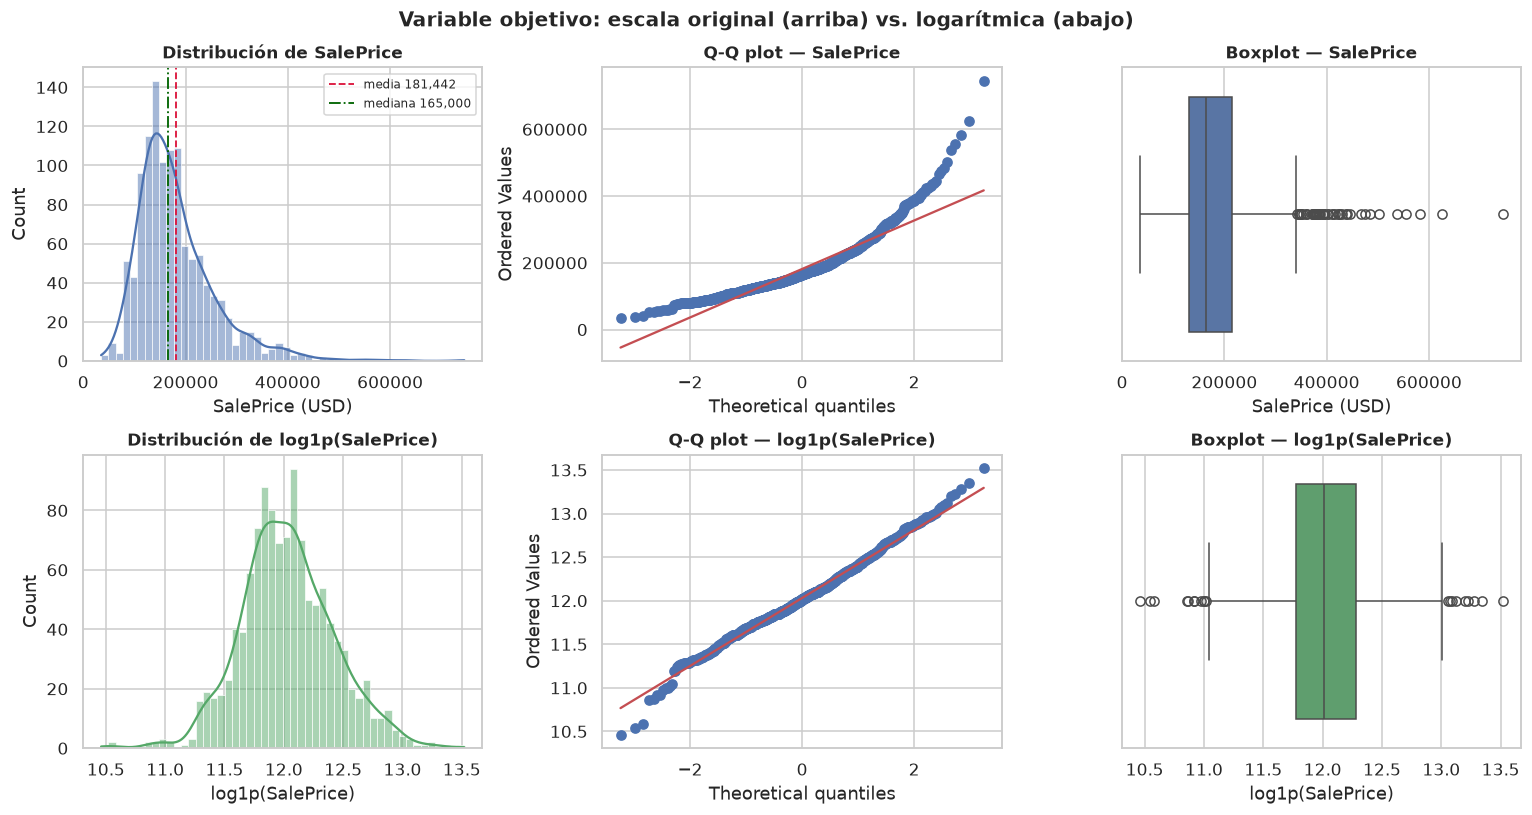

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7.5))

sns.histplot(y, bins=50, kde=True, ax=axes[0, 0], color="#4C72B0")
axes[0, 0].set_title("Distribución de SalePrice")
axes[0, 0].set_xlabel("SalePrice (USD)")
axes[0, 0].axvline(y.mean(), color="crimson", ls="--", lw=1.2, label=f"media {y.mean():,.0f}")
axes[0, 0].axvline(y.median(), color="darkgreen", ls="-.", lw=1.2, label=f"mediana {y.median():,.0f}")
axes[0, 0].legend(fontsize=8)

stats.probplot(y, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title("Q-Q plot — SalePrice")

sns.boxplot(x=y, ax=axes[0, 2], color="#4C72B0")
axes[0, 2].set_title("Boxplot — SalePrice")
axes[0, 2].set_xlabel("SalePrice (USD)")

log_y = np.log1p(y)
sns.histplot(log_y, bins=50, kde=True, ax=axes[1, 0], color="#55A868")
axes[1, 0].set_title("Distribución de log1p(SalePrice)")
axes[1, 0].set_xlabel("log1p(SalePrice)")

stats.probplot(log_y, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q plot — log1p(SalePrice)")

sns.boxplot(x=log_y, ax=axes[1, 2], color="#55A868")
axes[1, 2].set_title("Boxplot — log1p(SalePrice)")
axes[1, 2].set_xlabel("log1p(SalePrice)")

fig.suptitle("Variable objetivo: escala original (arriba) vs. logarítmica (abajo)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
save_fig(fig, "01_target_distribucion")
plt.show()

**Lectura.** `SalePrice` tiene asimetría positiva marcada (skew = 1.74, curtosis = 5.48) y una cola
derecha larga: la media supera a la mediana en ~16 k USD y el máximo (745 000 USD) está a 7.3
desviaciones estándar. El Q-Q plot se despega de la diagonal en ambos extremos y Shapiro-Wilk
rechaza la normalidad (W = 0.881, p ≈ 5·10⁻²⁹).

Aplicar `log1p` reduce la asimetría a 0.12 y alinea el Q-Q plot casi por completo. Esto tiene dos
consecuencias directas sobre el modelo:

- **Entrenar sobre `log1p(SalePrice)`** evita que un puñado de casas caras domine el gradiente
  del MSE, que penaliza el error absoluto y por tanto pesa mucho más los precios altos.
- La métrica de la competencia es **RMSE en la escala original**, así que las predicciones deben
  revertirse con `expm1` antes de evaluarlas. La decisión de si entrenar en log conviene o no
  para *esta* métrica debe validarse empíricamente en la sección 2.3 — es una hipótesis del EDA,
  no una conclusión.

---
## 4. Estadísticas descriptivas de las variables relevantes

In [12]:
num_cols_all = CONTINUOUS_COLS + DISCRETE_COLS + NUM_ORDINAL + TEMPORAL_COLS

desc_num = df[num_cols_all].describe().T
desc_num["rango"] = desc_num["max"] - desc_num["min"]
desc_num["skew"] = df[num_cols_all].skew()
desc_num["curtosis"] = df[num_cols_all].kurtosis()
desc_num["% ceros"] = (df[num_cols_all] == 0).mean().mul(100).round(1)
desc_num["% nulos"] = df[num_cols_all].isna().mean().mul(100).round(1)
desc_num["corr_target"] = df[num_cols_all].corrwith(y)

desc_num = desc_num[
    ["count", "mean", "50%", "std", "min", "max", "rango", "skew", "curtosis",
     "% ceros", "% nulos", "corr_target"]
].rename(columns={"count": "n", "mean": "media", "50%": "mediana", "std": "desv_est",
                  "min": "mín", "max": "máx"})

desc_num.sort_values("corr_target", ascending=False, key=abs).round(3)

,n,media,mediana,desv_est,mín,máx,rango,skew,curtosis,% ceros,% nulos,corr_target
OverallQual,1168.0,6.122,6.0,1.368,1.0,10.0,9.0,0.197,0.119,0.0,0.0,0.786
GrLivArea,1168.0,1527.402,1473.0,524.433,334.0,5642.0,5308.0,1.425,5.452,0.0,0.0,0.696
GarageCars,1168.0,1.782,2.0,0.740,0.0,4.0,4.0,-0.390,0.335,5.5,0.0,0.641
GarageArea,1168.0,476.274,482.0,211.095,0.0,1418.0,1418.0,0.109,0.879,5.5,0.0,0.624
TotalBsmtSF,1168.0,1061.771,997.5,440.676,0.0,6110.0,6110.0,1.724,15.678,2.4,0.0,0.598
1stFlrSF,1168.0,1169.354,1095.0,386.675,334.0,4692.0,4358.0,1.422,6.700,0.0,0.0,0.588
FullBath,1168.0,1.577,2.0,0.547,0.0,3.0,3.0,0.038,-0.906,0.4,0.0,0.553
TotRmsAbvGrd,1168.0,6.562,6.0,1.620,2.0,14.0,12.0,0.687,0.942,0.0,0.0,0.520
YearBuilt,1168.0,1970.966,1972.0,30.675,1872.0,2010.0,138.0,-0.623,-0.435,0.0,0.0,0.517
YearRemodAdd,1168.0,1984.897,1994.0,20.734,1950.0,2010.0,60.0,-0.508,-1.280,0.0,0.0,0.509


In [13]:
# Variables con escalas muy dispares → confirma la necesidad de estandarizar antes del MLP
escalas = desc_num[["media", "desv_est", "mín", "máx"]].copy()
escalas["orden_magnitud"] = np.log10(escalas["máx"].clip(lower=1)).round(1)
print("Rango de órdenes de magnitud entre features numéricas:")
print(f"  mínimo : 10^{escalas['orden_magnitud'].min():.1f}  ({escalas['orden_magnitud'].idxmin()})")
print(f"  máximo : 10^{escalas['orden_magnitud'].max():.1f}  ({escalas['orden_magnitud'].idxmax()})")
print("\nFeatures con mayor asimetría (candidatas a transformación log/Yeo-Johnson):")
print(df[num_cols_all].skew().sort_values(ascending=False).head(12).round(2).to_string())

Rango de órdenes de magnitud entre features numéricas:
  mínimo : 10^0.3  (BsmtHalfBath)
  máximo : 10^5.3  (LotArea)

Features con mayor asimetría (candidatas a transformación log/Yeo-Johnson):
MiscVal          22.05
PoolArea         14.40
LotArea          11.96
3SsnPorch         9.83
LowQualFinSF      9.20
KitchenAbvGr      4.45
BsmtFinSF2        4.22
ScreenPorch       4.09
BsmtHalfBath      4.01
EnclosedPorch     3.16
LotFrontage       2.41
OpenPorchSF       2.33


In [14]:
# Descriptivas de las categóricas: cardinalidad, moda y concentración
desc_cat = pd.DataFrame({
    "n_categorias": df[NOMINAL_COLS + ORDINAL_COLS].nunique(),
    "% nulos": df[NOMINAL_COLS + ORDINAL_COLS].isna().mean().mul(100).round(1),
    "moda": [df[c].mode(dropna=True)[0] for c in NOMINAL_COLS + ORDINAL_COLS],
    "% moda": [
        round(100 * df[c].value_counts().iloc[0] / df[c].notna().sum(), 1)
        for c in NOMINAL_COLS + ORDINAL_COLS
    ],
    "tipo": ["nominal"] * len(NOMINAL_COLS) + ["ordinal"] * len(ORDINAL_COLS),
}).sort_values("% moda", ascending=False)

print("Categóricas cuasi-constantes (>97 % en una sola categoría) — aportan poca señal:")
print(desc_cat.query("`% moda` > 97").to_string())
desc_cat.head(25)

Categóricas cuasi-constantes (>97 % en una sola categoría) — aportan poca señal:
            n_categorias  % nulos     moda  % moda     tipo
Utilities              2      0.0   AllPub    99.9  ordinal
Street                 2      0.0     Pave    99.7  nominal
Condition2             8      0.0     Norm    99.1  nominal
RoofMatl               7      0.0  CompShg    98.4  nominal
Heating                6      0.0     GasA    97.6  nominal


,n_categorias,% nulos,moda,% moda,tipo
Utilities,2,0.0,AllPub,99.9,ordinal
Street,2,0.0,Pave,99.7,nominal
Condition2,8,0.0,Norm,99.1,nominal
RoofMatl,7,0.0,CompShg,98.4,nominal
Heating,6,0.0,GasA,97.6,nominal
GarageCond,5,5.5,TA,96.1,ordinal
GarageQual,5,5.5,TA,95.1,ordinal
LandSlope,3,0.0,Gtl,94.9,ordinal
CentralAir,2,0.0,Y,92.9,ordinal
Functional,7,0.0,Typ,92.8,ordinal


---
## 5. Valores nulos

Tras corregir el parsing (§1.1), quedan dos fenómenos distintos que siguen compartiendo el mismo
`NaN` y que **no** deben tratarse igual:

- **`NA` estructural** — el campo viene vacío porque *la vivienda no tiene esa característica*.
  `PoolQC` vacío significa **"no hay piscina"**, no "se perdió el dato". Imputar aquí con la moda
  inventaría información falsa: le asignaría una calidad de piscina a casas sin piscina.
- **Dato faltante genuino** — el valor existe en la realidad pero no se registró
  (`LotFrontage`, `Electrical`, `MasVnrArea`, `MasVnrType`). Aquí sí corresponde imputar.

La distinción no se asume: se **verifica** cruzando cada bloque contra su variable de área
correspondiente (una casa sin `BsmtQual` debe tener `TotalBsmtSF == 0`).

In [15]:
# Columnas donde 'NA' es una categoría válida según el diccionario de datos de Ames
NA_ESTRUCTURAL = [
    "Alley", "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "FireplaceQu", "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "PoolQC", "Fence", "MiscFeature", "GarageYrBlt",
]

nulos = df.isna().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)

tabla_nulos = pd.DataFrame({
    "n_nulos": nulos,
    "% nulos": (100 * nulos / len(df)).round(2),
    "interpretación": [
        "NA estructural (no posee la característica)" if c in NA_ESTRUCTURAL
        else "faltante genuino (requiere imputación)"
        for c in nulos.index
    ],
})
print(f"Columnas con al menos un nulo: {len(nulos)} de {df.shape[1]}")
print(f"Celdas nulas totales: {df.isna().sum().sum():,} "
      f"({100 * df.isna().sum().sum() / df.size:.2f} % de la matriz)")
print(f"Filas sin ningún nulo: {(~df.isna().any(axis=1)).sum()} de {len(df)}\n")
tabla_nulos

Columnas con al menos un nulo: 19 de 81
Celdas nulas totales: 5,550 (5.87 % de la matriz)
Filas sin ningún nulo: 0 de 1168



,n_nulos,% nulos,interpretación
PoolQC,1162,99.49,NA estructural (no posee la característica)
MiscFeature,1122,96.06,NA estructural (no posee la característica)
Alley,1094,93.66,NA estructural (no posee la característica)
Fence,935,80.05,NA estructural (no posee la característica)
FireplaceQu,547,46.83,NA estructural (no posee la característica)
LotFrontage,217,18.58,faltante genuino (requiere imputación)
GarageCond,64,5.48,NA estructural (no posee la característica)
GarageType,64,5.48,NA estructural (no posee la característica)
GarageYrBlt,64,5.48,NA estructural (no posee la característica)
GarageFinish,64,5.48,NA estructural (no posee la característica)


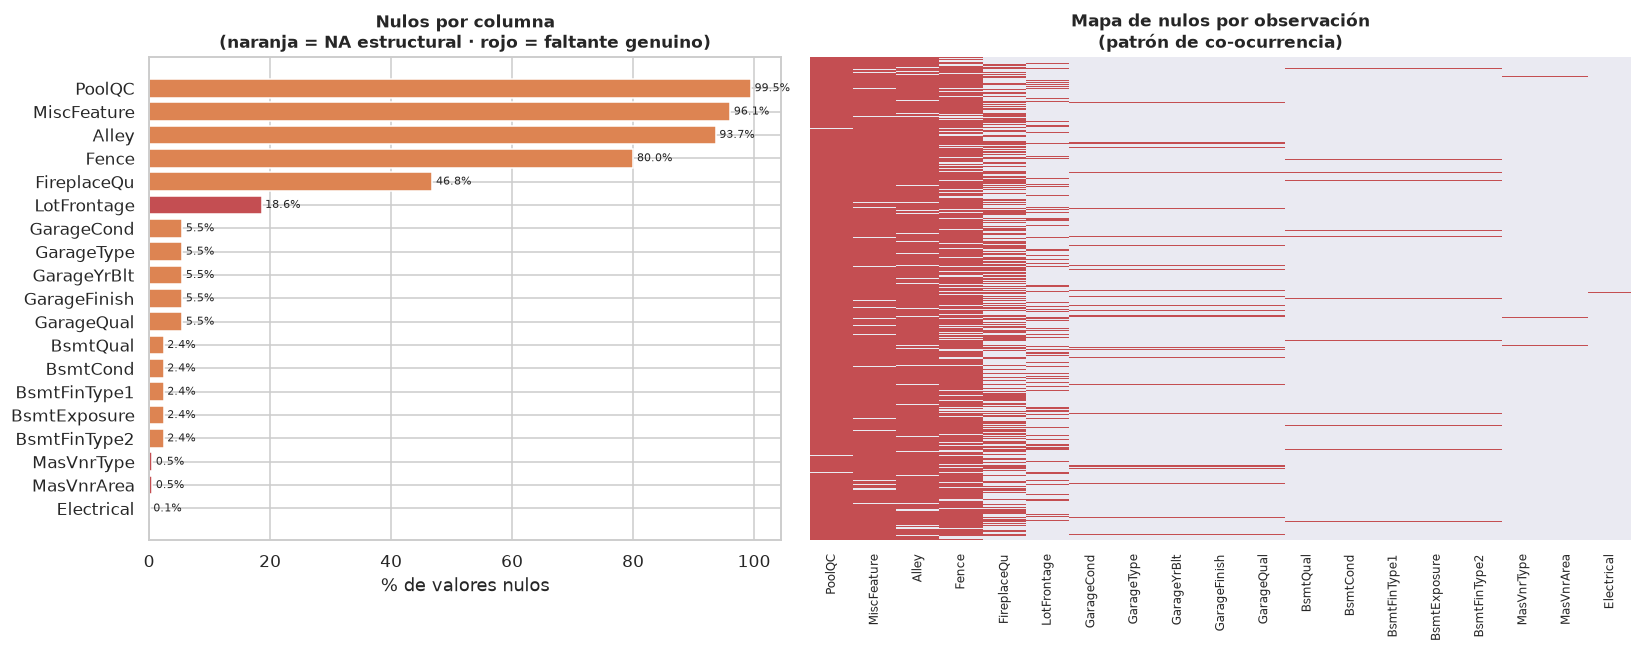

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={"width_ratios": [1, 1.3]})

colores = ["#DD8452" if c in NA_ESTRUCTURAL else "#C44E52" for c in tabla_nulos.index]
axes[0].barh(tabla_nulos.index[::-1], tabla_nulos["% nulos"][::-1], color=colores[::-1])
axes[0].set_xlabel("% de valores nulos")
axes[0].set_title("Nulos por columna\n(naranja = NA estructural · rojo = faltante genuino)")
for i, v in enumerate(tabla_nulos["% nulos"][::-1]):
    axes[0].text(v + 0.6, i, f"{v:.1f}%", va="center", fontsize=7.5)

sns.heatmap(df[tabla_nulos.index].isna(), cbar=False, ax=axes[1],
            cmap=["#EAEAF2", "#C44E52"], yticklabels=False)
axes[1].set_title("Mapa de nulos por observación\n(patrón de co-ocurrencia)")
axes[1].tick_params(axis="x", labelsize=8, rotation=90)

fig.tight_layout()
save_fig(fig, "02_valores_nulos")
plt.show()

In [17]:
# ¿Los nulos co-ocurren? Si un bloque de columnas falta siempre junto, confirma el NA estructural.
grupos = {
    "Sótano":  ["BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2"],
    "Garaje":  ["GarageType", "GarageYrBlt", "GarageFinish", "GarageQual", "GarageCond"],
}
for nombre, cols in grupos.items():
    faltan = df[cols].isna().sum(axis=1)
    coherentes = ((faltan == 0) | (faltan == len(cols))).sum()
    print(f"{nombre}: {coherentes}/{len(df)} filas ({100*coherentes/len(df):.1f} %) "
          f"tienen las {len(cols)} columnas o todas presentes o todas nulas")
    print(f"  Filas con nulos parciales: {((faltan > 0) & (faltan < len(cols))).sum()}")

# Verificación cruzada contra las columnas numéricas correspondientes
print("\nCoherencia con las variables numéricas:")
sin_sotano = df["BsmtQual"].isna()
print(f"  TotalBsmtSF == 0 cuando BsmtQual es NA : "
      f"{(df.loc[sin_sotano, 'TotalBsmtSF'] == 0).all()}  (n={sin_sotano.sum()})")
sin_garaje = df["GarageType"].isna()
print(f"  GarageArea == 0 cuando GarageType es NA: "
      f"{(df.loc[sin_garaje, 'GarageArea'] == 0).all()}  (n={sin_garaje.sum()})")
sin_piscina = df["PoolQC"].isna()
print(f"  PoolArea  == 0 cuando PoolQC es NA     : "
      f"{(df.loc[sin_piscina, 'PoolArea'] == 0).all()}  (n={sin_piscina.sum()})")

Sótano: 1168/1168 filas (100.0 %) tienen las 5 columnas o todas presentes o todas nulas
  Filas con nulos parciales: 0
Garaje: 1168/1168 filas (100.0 %) tienen las 5 columnas o todas presentes o todas nulas
  Filas con nulos parciales: 0

Coherencia con las variables numéricas:
  TotalBsmtSF == 0 cuando BsmtQual es NA : True  (n=28)
  GarageArea == 0 cuando GarageType es NA: True  (n=64)
  PoolArea  == 0 cuando PoolQC es NA     : True  (n=1162)


In [18]:
# LotFrontage es el único faltante genuino masivo: ¿es aleatorio o tiene estructura?
frontage_na = df["LotFrontage"].isna()
print(f"LotFrontage: {frontage_na.sum()} nulos ({100*frontage_na.mean():.1f} %)\n")

comp = pd.DataFrame({
    "con LotFrontage": df.loc[~frontage_na, TARGET].describe(),
    "sin LotFrontage": df.loc[frontage_na, TARGET].describe(),
}).round(0)
t_stat, t_p = stats.ttest_ind(df.loc[~frontage_na, TARGET], df.loc[frontage_na, TARGET],
                              equal_var=False)
print(comp.to_string())
print(f"\nt-test de SalePrice entre ambos grupos: t={t_stat:.3f}, p={t_p:.3f}")
print("→ p > 0.05: la ausencia de LotFrontage no se asocia al precio (compatible con MAR/MCAR)\n")

mediana_barrio = df.groupby("Neighborhood")["LotFrontage"].median()
print("Mediana de LotFrontage por barrio (justifica imputar por grupo, no global):")
print(f"  global : {df['LotFrontage'].median():.1f} ft")
print(f"  rango entre barrios: {mediana_barrio.min():.1f} – {mediana_barrio.max():.1f} ft")
print(mediana_barrio.sort_values().head(5).round(1).to_string())

LotFrontage: 217 nulos (18.6 %)

       con LotFrontage  sin LotFrontage
count            951.0            217.0
mean          181601.0         180741.0
std            80983.0          58379.0
min            34900.0          61000.0
25%           128700.0         143000.0
50%           163000.0         171750.0
75%           214000.0         215000.0
max           745000.0         466500.0

t-test de SalePrice entre ambos grupos: t=0.181, p=0.856
→ p > 0.05: la ausencia de LotFrontage no se asocia al precio (compatible con MAR/MCAR)

Mediana de LotFrontage por barrio (justifica imputar por grupo, no global):
  global : 70.0 ft
  rango entre barrios: 21.0 – 91.5 ft
Neighborhood
BrDale     21.0
MeadowV    21.0
NPkVill    24.0
Blueste    24.0
Blmngtn    43.0


---
## 6. Valores atípicos (outliers)

Se combinan tres lecturas: la regla del IQR, el z-score, y —lo más importante— la inspección
**bivariada** contra el target, que es la que distingue un valor extremo *legítimo* (una casa
grande y cara) de un punto *influyente* que rompe la relación (una casa enorme y barata).

In [19]:
def resumen_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    z = np.abs(stats.zscore(s.dropna()))
    return pd.Series({
        "n_iqr": int(((s < lo) | (s > hi)).sum()),
        "%_iqr": round(100 * ((s < lo) | (s > hi)).mean(), 1),
        "n_z>3": int((z > 3).sum()),
        "límite_inf": round(lo, 1),
        "límite_sup": round(hi, 1),
        "máx_observado": round(s.max(), 1),
    })

cont_relevantes = [c for c in CONTINUOUS_COLS if (df[c] != 0).mean() > 0.5]
tabla_out = df[cont_relevantes + [TARGET]].apply(resumen_outliers).T
tabla_out.sort_values("%_iqr", ascending=False)

,n_iqr,%_iqr,n_z>3,límite_inf,límite_sup,máx_observado
LotFrontage,68.0,5.8,10.0,27.5,111.5,313.0
OpenPorchSF,60.0,5.1,23.0,-111.0,185.0,547.0
LotArea,54.0,4.6,12.0,1418.1,17869.1,215245.0
SalePrice,48.0,4.1,17.0,2612.5,342312.5,745000.0
TotalBsmtSF,47.0,4.0,8.0,41.1,2054.1,6110.0
GrLivArea,23.0,2.0,15.0,176.4,2761.4,5642.0
BsmtUnfSF,21.0,1.8,7.0,-659.1,1691.9,2336.0
GarageArea,18.0,1.5,5.0,-11.5,928.5,1418.0
1stFlrSF,13.0,1.1,8.0,124.9,2159.9,4692.0
BsmtFinSF1,5.0,0.4,4.0,-1081.5,1802.5,5644.0


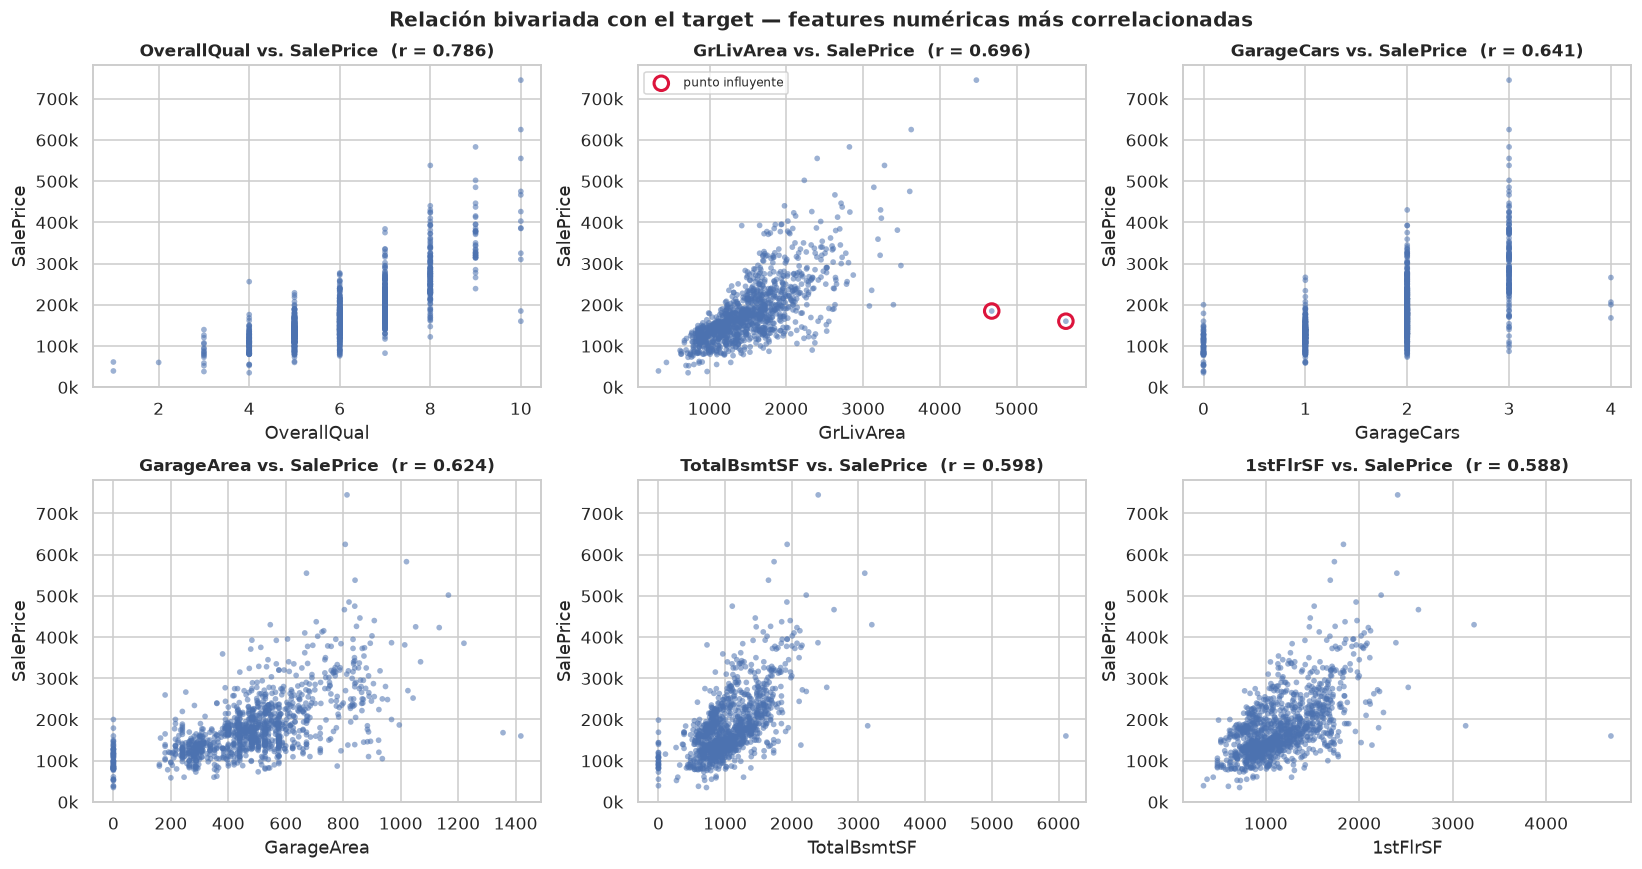

Casas con GrLivArea > 4000 ft² y precio < 300 k USD: 2
  Id  GrLivArea  OverallQual SaleCondition  SalePrice
 524       4676           10       Partial     184750
1299       5642           10       Partial     160000


In [20]:
top_corr = df[num_cols_all].corrwith(y).abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), top_corr):
    ax.scatter(df[col], y, s=14, alpha=0.55, edgecolor="none", color="#4C72B0")
    r = df[col].corr(y)
    ax.set_title(f"{col} vs. SalePrice  (r = {r:.3f})")
    ax.set_xlabel(col)
    ax.set_ylabel("SalePrice")
    ax.yaxis.set_major_formatter(lambda v, p: f"{v/1000:.0f}k")

# Marcar los casos influyentes clásicos de Ames: casas enormes vendidas muy barato
influyentes = df[(df["GrLivArea"] > 4000) & (df[TARGET] < 300_000)]
if len(influyentes) and "GrLivArea" in top_corr:
    ax = axes.ravel()[top_corr.index("GrLivArea")]
    ax.scatter(influyentes["GrLivArea"], influyentes[TARGET], s=90,
               facecolor="none", edgecolor="crimson", lw=2, label="punto influyente")
    ax.legend(fontsize=8)

fig.suptitle("Relación bivariada con el target — features numéricas más correlacionadas",
             fontsize=13, fontweight="bold")
fig.tight_layout()
save_fig(fig, "03_outliers_bivariados")
plt.show()

print(f"Casas con GrLivArea > 4000 ft² y precio < 300 k USD: {len(influyentes)}")
if len(influyentes):
    print(influyentes[["Id", "GrLivArea", "OverallQual", "SaleCondition", TARGET]].to_string(index=False))

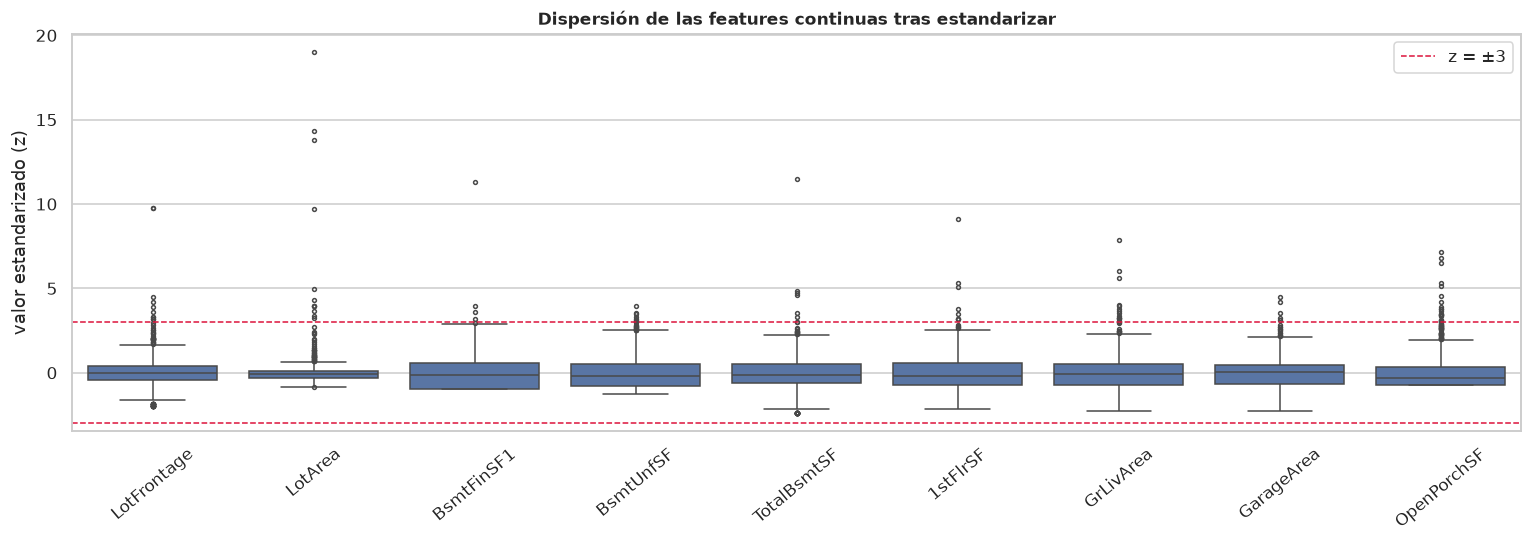

In [21]:
fig, ax = plt.subplots(figsize=(14, 5))
cont_plot = [c for c in cont_relevantes if c != TARGET][:12]
df_z = df[cont_plot].apply(lambda s: (s - s.mean()) / s.std())
sns.boxplot(data=df_z, ax=ax, fliersize=2.5, color="#4C72B0")
ax.axhline(3, color="crimson", ls="--", lw=1, label="z = ±3")
ax.axhline(-3, color="crimson", ls="--", lw=1)
ax.set_ylabel("valor estandarizado (z)")
ax.set_title("Dispersión de las features continuas tras estandarizar")
ax.tick_params(axis="x", rotation=40)
ax.legend()
fig.tight_layout()
save_fig(fig, "04_outliers_boxplots")
plt.show()

**Criterio adoptado.** No se eliminan outliers de forma masiva por regla del IQR: en variables como
`LotArea` o `TotalBsmtSF` los valores extremos son viviendas reales, y el conjunto de prueba del
día de la competencia contendrá casos igualmente extremos. Recortarlos del entrenamiento le
quitaría al modelo la capacidad de predecirlos.

La excepción son los **puntos influyentes** con `GrLivArea > 4000` y precio bajo, que corresponden
a ventas parciales (`SaleCondition = Partial`) de casas sin terminar: rompen la relación
área–precio y son ampliamente documentados como anomalías del dataset Ames. Su eliminación se
tratará como una **iteración con A/B explícito** en la sección 2.3, no como un hecho consumado.

---
## 7. Inconsistencias lógicas

Chequeos de integridad: relaciones que *deben* cumplirse por definición del dominio y cuya
violación indica error de captura.

In [22]:
checks = []

def chk(nombre, mask, detalle=""):
    checks.append({"chequeo": nombre, "n_violaciones": int(mask.sum()), "detalle": detalle})

chk("Remodelación anterior a la construcción",
    df["YearRemodAdd"] < df["YearBuilt"], "YearRemodAdd < YearBuilt")
chk("Garaje construido antes que la casa",
    df["GarageYrBlt"] < df["YearBuilt"], "GarageYrBlt < YearBuilt")
chk("Garaje construido después de la venta",
    df["GarageYrBlt"] > df["YrSold"], "GarageYrBlt > YrSold")
chk("Casa construida después de la venta",
    df["YearBuilt"] > df["YrSold"], "YearBuilt > YrSold")
chk("Componentes del sótano no suman el total",
    (df["BsmtFinSF1"] + df["BsmtFinSF2"] + df["BsmtUnfSF"] - df["TotalBsmtSF"]).abs() > 1,
    "BsmtFinSF1+BsmtFinSF2+BsmtUnfSF != TotalBsmtSF")
chk("Superficies de piso no suman GrLivArea",
    (df["1stFlrSF"] + df["2ndFlrSF"] + df["LowQualFinSF"] - df["GrLivArea"]).abs() > 1,
    "1stFlrSF+2ndFlrSF+LowQualFinSF != GrLivArea")
chk("Piscina con área > 0 pero sin PoolQC",
    (df["PoolArea"] > 0) & df["PoolQC"].isna(), "PoolArea > 0 & PoolQC nulo")
chk("Garaje con autos pero sin área",
    (df["GarageCars"] > 0) & (df["GarageArea"] == 0), "GarageCars > 0 & GarageArea == 0")
chk("Vivienda sin ningún baño completo",
    (df["FullBath"] + df["BsmtFullBath"]) == 0, "FullBath + BsmtFullBath == 0")
chk("Vivienda sin dormitorios sobre rasante",
    df["BedroomAbvGr"] == 0, "BedroomAbvGr == 0")
chk("Área habitable no positiva", df["GrLivArea"] <= 0, "GrLivArea <= 0")
chk("Precio de venta no positivo", df[TARGET] <= 0, "SalePrice <= 0")

tabla_checks = pd.DataFrame(checks).sort_values("n_violaciones", ascending=False).reset_index(drop=True)
print(f"Chequeos ejecutados: {len(tabla_checks)} | con violaciones: {(tabla_checks['n_violaciones'] > 0).sum()}")
tabla_checks

Chequeos ejecutados: 12 | con violaciones: 2


,chequeo,n_violaciones,detalle
0,Garaje construido antes que la casa,5,GarageYrBlt < YearBuilt
1,Vivienda sin dormitorios sobre rasante,4,BedroomAbvGr == 0
2,Garaje construido después de la venta,0,GarageYrBlt > YrSold
3,Remodelación anterior a la construcción,0,YearRemodAdd < YearBuilt
4,Casa construida después de la venta,0,YearBuilt > YrSold
5,Componentes del sótano no suman el total,0,BsmtFinSF1+BsmtFinSF2+BsmtUnfSF != TotalBsmtSF
6,Piscina con área > 0 pero sin PoolQC,0,PoolArea > 0 & PoolQC nulo
7,Superficies de piso no suman GrLivArea,0,1stFlrSF+2ndFlrSF+LowQualFinSF != GrLivArea
8,Garaje con autos pero sin área,0,GarageCars > 0 & GarageArea == 0
9,Vivienda sin ningún baño completo,0,FullBath + BsmtFullBath == 0


Dos chequeos fallan. Ninguno invalida el dato, pero conviene documentar la interpretación:

In [23]:
print("① Garaje construido antes que la vivienda (5 casos)")
print(df.loc[df["GarageYrBlt"] < df["YearBuilt"],
             [ID_COL, "YearBuilt", "YearRemodAdd", "GarageYrBlt", "GarageType", TARGET]]
        .to_string(index=False))
print("\n   Diferencia en años:",
      (df["YearBuilt"] - df["GarageYrBlt"]).loc[lambda s: s > 0].tolist())
print("   → Desfases de 1 a 10 años en casas antiguas o remodeladas. Es plausible que el garaje")
print("     provenga de una estructura previa del lote, o que sea un error de captura menor.")
print("     Impacto acotado (0.4 % de las filas); no se eliminan las filas.\n")

print("② Viviendas sin dormitorios sobre rasante (4 casos)")
print(df.loc[df["BedroomAbvGr"] == 0,
             [ID_COL, "BedroomAbvGr", "TotRmsAbvGrd", "GrLivArea", "MSSubClass", TARGET]]
        .to_string(index=False))
print("\n   → No es un error: son viviendas con dormitorios en el sótano o plantas atípicas")
print("     (MSSubClass 20/40/80/120). Tienen habitaciones (TotRmsAbvGrd entre 3 y 5) y precios")
print("     normales o altos. Se conservan tal cual.")

① Garaje construido antes que la vivienda (5 casos)
  Id  YearBuilt  YearRemodAdd  GarageYrBlt GarageType  SalePrice
1419       1963          1963       1962.0     Detchd     124000
1377       1930          1950       1925.0     Detchd      91000
1104       1959          1959       1954.0    BuiltIn     159500
  94       1910          1998       1900.0     Detchd     133900
 601       2005          2005       2003.0    BuiltIn     275000

   Diferencia en años: [1.0, 5.0, 5.0, 10.0, 2.0]
   → Desfases de 1 a 10 años en casas antiguas o remodeladas. Es plausible que el garaje
     provenga de una estructura previa del lote, o que sea un error de captura menor.
     Impacto acotado (0.4 % de las filas); no se eliminan las filas.

② Viviendas sin dormitorios sobre rasante (4 casos)
  Id  BedroomAbvGr  TotRmsAbvGrd  GrLivArea  MSSubClass  SalePrice
1214             0             3        960          80     145000
1271             0             4       1524          40     260000
  54     

In [24]:
# Columnas cuasi-constantes: no aportan varianza y sí dimensionalidad
casi_const = []
for c in df.columns.drop([ID_COL, TARGET]):
    frac = df[c].value_counts(dropna=False).iloc[0] / len(df)
    if frac > 0.97:
        casi_const.append((c, round(100 * frac, 2), df[c].mode(dropna=False)[0]))

casi_const_df = pd.DataFrame(casi_const, columns=["columna", "% valor dominante", "valor"]) \
                  .sort_values("% valor dominante", ascending=False).reset_index(drop=True)
print(f"Columnas cuasi-constantes (>97 % en un solo valor): {len(casi_const_df)}")
casi_const_df

Columnas cuasi-constantes (>97 % en un solo valor): 9


,columna,% valor dominante,valor
0,Utilities,99.91,AllPub
1,Street,99.66,Pave
2,PoolQC,99.49,NaN
3,PoolArea,99.49,0
4,Condition2,99.06,Norm
5,RoofMatl,98.37,CompShg
6,3SsnPorch,98.29,0
7,LowQualFinSF,98.20,0
8,Heating,97.60,GasA


In [25]:
# Cobertura temporal y categorías con muy pocas observaciones (riesgo en el split y en el test)
print("Cobertura temporal del dataset:")
print(f"  Años de venta       : {df['YrSold'].min()} – {df['YrSold'].max()}")
print(f"  Años de construcción: {df['YearBuilt'].min()} – {df['YearBuilt'].max()}")
print(df["YrSold"].value_counts().sort_index().to_string())

print("\nCategorías con menos de 5 observaciones (se agruparán en 'Other'):")
raras = []
for c in NOMINAL_COLS:
    vc = df[c].value_counts()
    for nivel, n in vc[vc < 5].items():
        raras.append((c, nivel, int(n)))
raras_df = pd.DataFrame(raras, columns=["columna", "categoría", "n"]).sort_values("n")
print(f"  Total de niveles raros: {len(raras_df)} en {raras_df['columna'].nunique()} columnas")
raras_df.head(20)

Cobertura temporal del dataset:
  Años de venta       : 2006 – 2010
  Años de construcción: 1872 – 2010
YrSold
2006    250
2007    260
2008    246
2009    276
2010    136

Categorías con menos de 5 observaciones (se agruparán en 'Other'):
  Total de niveles raros: 42 en 17 columnas


,columna,categoría,n
3,Neighborhood,Blueste,1
4,Condition1,RRNe,1
9,Condition2,PosA,1
15,RoofMatl,Metal,1
11,Condition2,RRAn,1
10,Condition2,RRAe,1
8,Condition2,RRNn,1
30,Heating,Floor,1
25,Exterior2nd,Other,1
26,Exterior2nd,CBlock,1


---
## 8. Correlaciones entre features

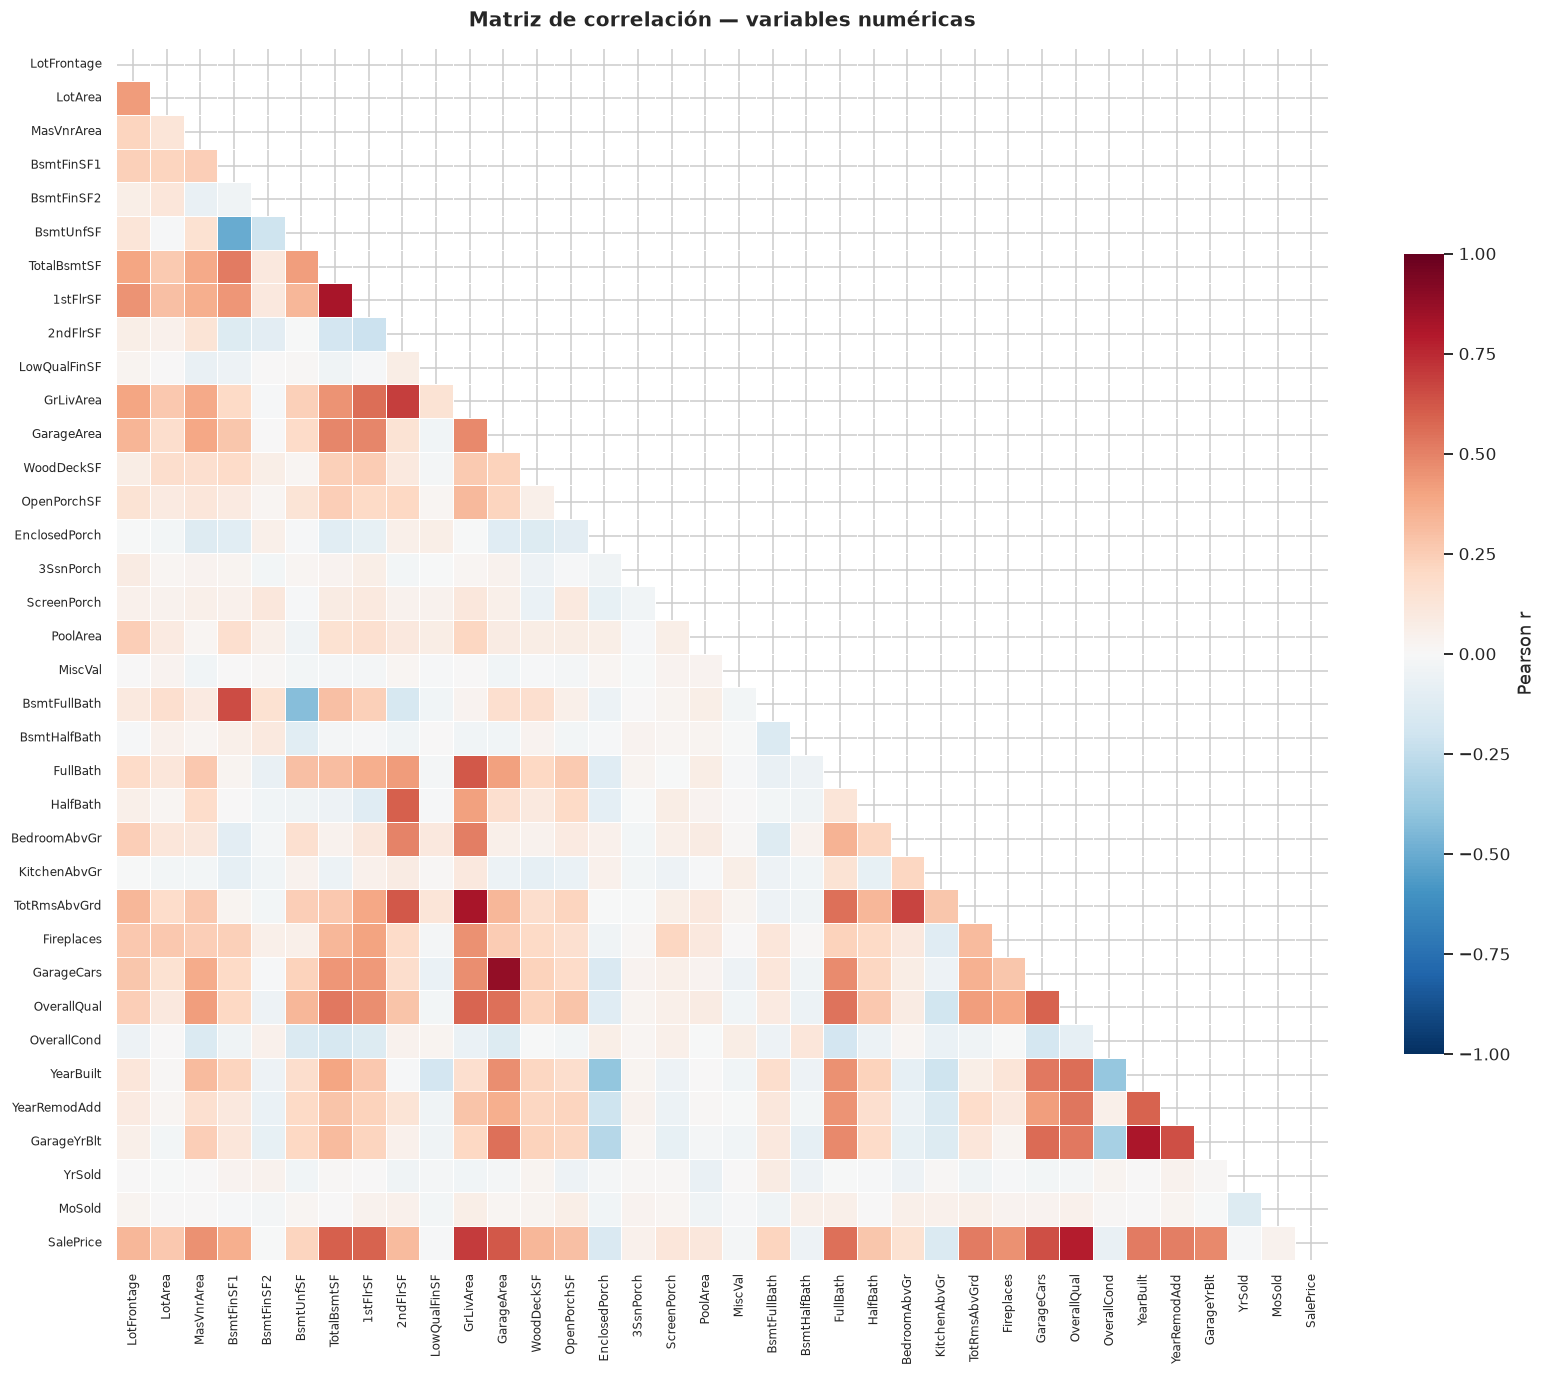

In [26]:
corr = df[num_cols_all + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(15, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.4, cbar_kws={"shrink": 0.6, "label": "Pearson r"},
            ax=ax)
ax.set_title("Matriz de correlación — variables numéricas", fontsize=13, fontweight="bold", pad=14)
ax.tick_params(labelsize=8)
fig.tight_layout()
save_fig(fig, "05_matriz_correlacion")
plt.show()

In [27]:
# Multicolinealidad: pares de features fuertemente correlacionadas entre sí
pares = (
    corr.drop(index=TARGET, columns=TARGET)
        .where(np.triu(np.ones(corr.shape[0] - 1, dtype=bool), k=1))
        .stack()
        .rename("r")
        .reset_index()
        .rename(columns={"level_0": "feature_A", "level_1": "feature_B"})
)
pares["|r|"] = pares["r"].abs()
altos = pares.query("`|r|` >= 0.65").sort_values("|r|", ascending=False).reset_index(drop=True)
altos["corr_A_target"] = altos["feature_A"].map(corr[TARGET]).round(3)
altos["corr_B_target"] = altos["feature_B"].map(corr[TARGET]).round(3)
print(f"Pares con |r| >= 0.65: {len(altos)}")
altos.round(3)

Pares con |r| >= 0.65: 6


,feature_A,feature_B,r,|r|,corr_A_target,corr_B_target
0,GarageArea,GarageCars,0.883,0.883,0.624,0.641
1,TotalBsmtSF,1stFlrSF,0.827,0.827,0.598,0.588
2,GrLivArea,TotRmsAbvGrd,0.821,0.821,0.696,0.520
3,YearBuilt,GarageYrBlt,0.820,0.820,0.517,0.480
4,2ndFlrSF,GrLivArea,0.688,0.688,0.314,0.696
5,BedroomAbvGr,TotRmsAbvGrd,0.679,0.679,0.156,0.520


**Nota.** Un MLP no colapsa ante la multicolinealidad como lo haría una regresión lineal (no hay
inversión de matriz), pero la redundancia sí infla el número de parámetros y agrava el sobreajuste
con solo 1168 filas. Los pares detectados (`GarageCars`/`GarageArea`, `TotRmsAbvGrd`/`GrLivArea`,
`1stFlrSF`/`TotalBsmtSF`, `YearBuilt`/`GarageYrBlt`) son candidatos a consolidarse en una sola
feature — algo que se probará como iteración, comparando contra el baseline que las conserva todas.

---
## 9. Relación de cada feature con la variable objetivo

Para las numéricas se usa el coeficiente de Pearson (y Spearman, robusto a no linealidad).
Para las categóricas, Pearson no aplica: se usa la **razón de correlación η²**, que mide qué
fracción de la varianza de `SalePrice` explica la partición inducida por la categoría.

In [28]:
rank_num = pd.DataFrame({
    "pearson": df[num_cols_all].corrwith(y),
    "spearman": df[num_cols_all].corrwith(y, method="spearman"),
    "pearson_log": df[num_cols_all].corrwith(np.log1p(y)),
}).round(3)
rank_num["|pearson|"] = rank_num["pearson"].abs()
rank_num["gana_con_log"] = (rank_num["pearson_log"].abs() > rank_num["|pearson|"]).map(
    {True: "sí", False: "no"})
rank_num = rank_num.sort_values("|pearson|", ascending=False)
rank_num.head(25)

,pearson,spearman,pearson_log,|pearson|,gana_con_log
OverallQual,0.786,0.801,0.808,0.786,sí
GrLivArea,0.696,0.723,0.689,0.696,no
GarageCars,0.641,0.687,0.684,0.641,sí
GarageArea,0.624,0.639,0.655,0.624,sí
TotalBsmtSF,0.598,0.595,0.597,0.598,no
1stFlrSF,0.588,0.566,0.581,0.588,no
FullBath,0.553,0.626,0.584,0.553,sí
TotRmsAbvGrd,0.520,0.521,0.520,0.520,no
YearBuilt,0.517,0.643,0.577,0.517,sí
YearRemodAdd,0.509,0.563,0.562,0.509,sí


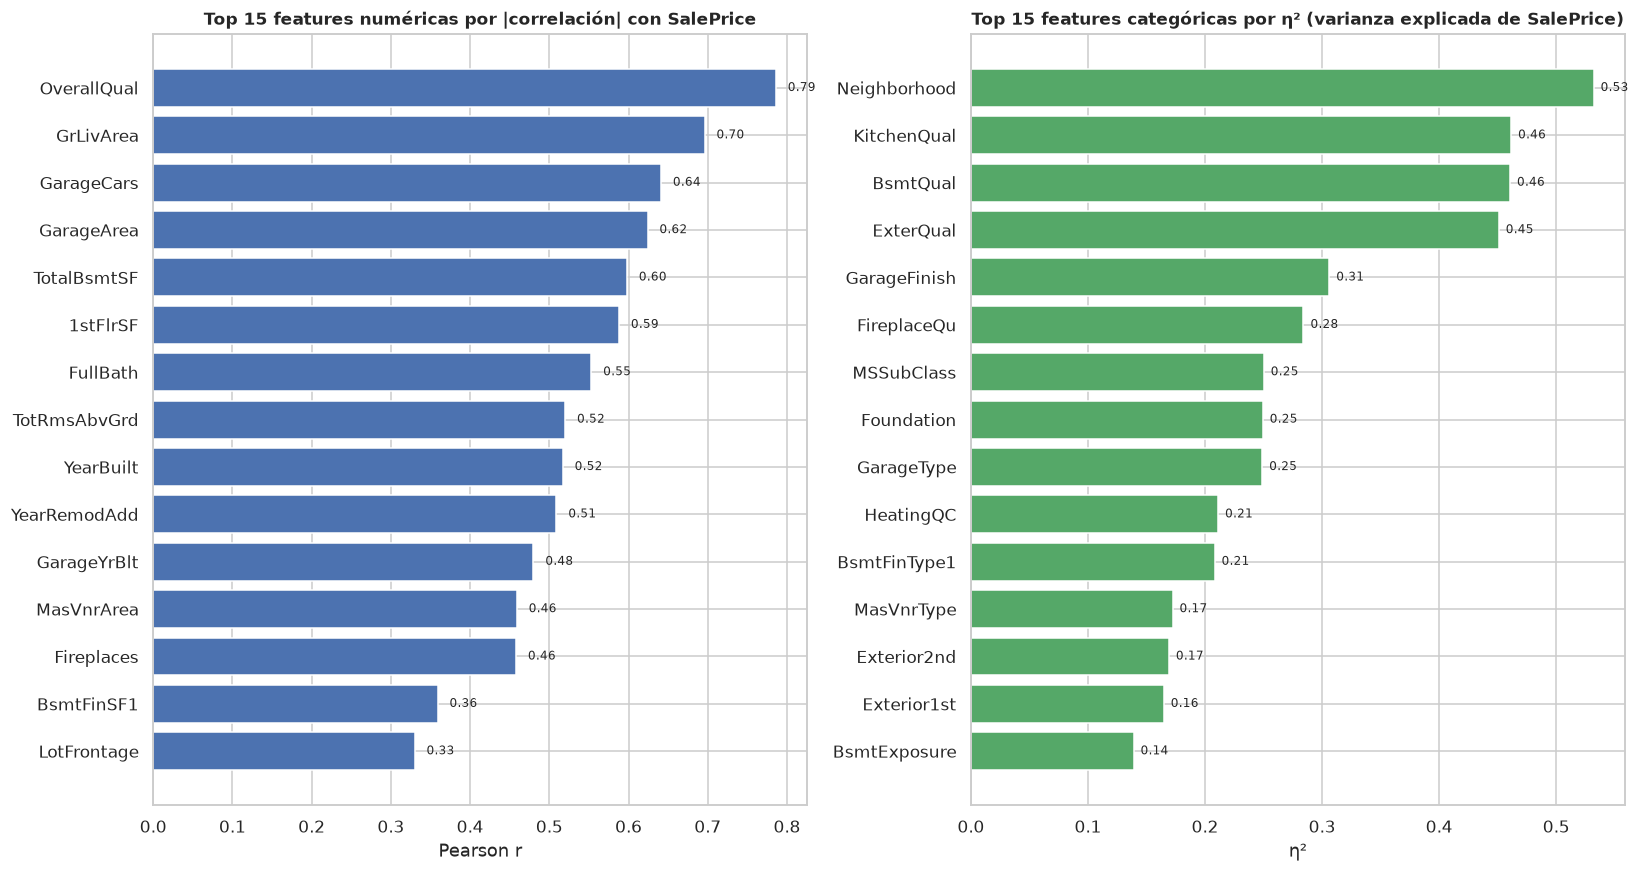

η² de todas las categóricas (ordenado):
Neighborhood     0.532
KitchenQual      0.461
BsmtQual         0.460
ExterQual        0.451
GarageFinish     0.306
FireplaceQu      0.284
MSSubClass       0.250
Foundation       0.249
GarageType       0.249
HeatingQC        0.211
BsmtFinType1     0.208
MasVnrType       0.172
Exterior2nd      0.169
Exterior1st      0.165
BsmtExposure     0.139
SaleCondition    0.129
SaleType         0.129
MSZoning         0.096
HouseStyle       0.090
GarageQual       0.086
GarageCond       0.085
CentralAir       0.072
LotShape         0.070
RoofStyle        0.059
Electrical       0.057
PavedDrive       0.054
BsmtCond         0.053
BldgType         0.036
Condition1       0.036
Fence            0.035
LandContour      0.032
BsmtFinType2     0.032
PoolQC           0.028
ExterCond        0.025
LotConfig        0.023
Alley            0.022
Functional       0.018
Heating          0.017
RoofMatl         0.014
Condition2       0.010
MiscFeature      0.006
LandSlope        

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8), sharey=False)

top15 = rank_num.head(15).sort_values("pearson")
axes[0].barh(top15.index, top15["pearson"],
             color=["#C44E52" if v < 0 else "#4C72B0" for v in top15["pearson"]])
axes[0].set_title("Top 15 features numéricas por |correlación| con SalePrice")
axes[0].set_xlabel("Pearson r")
for i, v in enumerate(top15["pearson"]):
    axes[0].text(v + (0.015 if v >= 0 else -0.055), i, f"{v:.2f}", va="center", fontsize=8)


def eta_squared(grupos, valores):
    """Razón de correlación: varianza de y explicada por la variable categórica."""
    media_global = valores.mean()
    ss_total = ((valores - media_global) ** 2).sum()
    ss_entre = sum(
        len(g) * (g.mean() - media_global) ** 2
        for _, g in valores.groupby(grupos, observed=True)
    )
    return ss_entre / ss_total if ss_total else np.nan


eta = pd.Series(
    {c: eta_squared(df[c].fillna("NA"), y) for c in NOMINAL_COLS + ORDINAL_COLS}
).sort_values(ascending=False)

top15_cat = eta.head(15).sort_values()
axes[1].barh(top15_cat.index, top15_cat.values, color="#55A868")
axes[1].set_title("Top 15 features categóricas por η² (varianza explicada de SalePrice)")
axes[1].set_xlabel("η²")
for i, v in enumerate(top15_cat.values):
    axes[1].text(v + 0.006, i, f"{v:.2f}", va="center", fontsize=8)

fig.tight_layout()
save_fig(fig, "06_ranking_features")
plt.show()

print("η² de todas las categóricas (ordenado):")
print(eta.round(3).to_string())

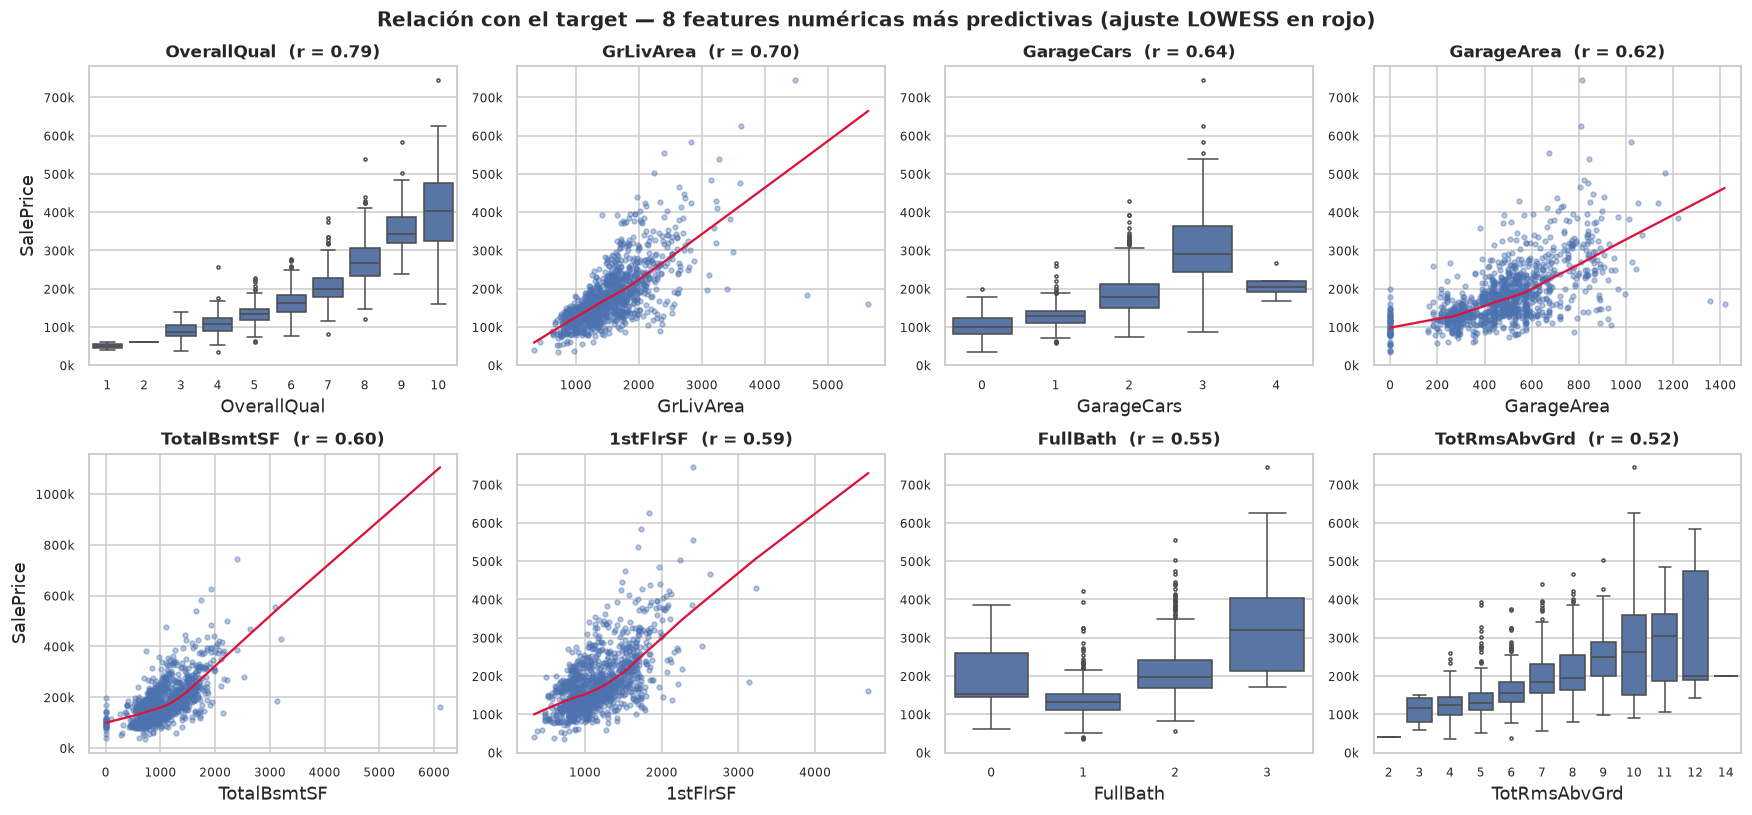

In [30]:
top_num = rank_num.head(8).index.tolist()
fig, axes = plt.subplots(2, 4, figsize=(16, 7.5))
for ax, col in zip(axes.ravel(), top_num):
    if df[col].nunique() <= 12:
        sns.boxplot(x=df[col], y=y, ax=ax, color="#4C72B0", fliersize=2)
    else:
        sns.regplot(x=df[col], y=y, ax=ax, scatter_kws=dict(s=10, alpha=0.4),
                    line_kws=dict(color="crimson", lw=1.5), lowess=True)
    ax.set_title(f"{col}  (r = {rank_num.loc[col, 'pearson']:.2f})")
    ax.set_xlabel(col)
    ax.set_ylabel("SalePrice" if ax in axes[:, 0] else "")
    ax.yaxis.set_major_formatter(lambda v, p: f"{v/1000:.0f}k")
    ax.tick_params(labelsize=8)

fig.suptitle("Relación con el target — 8 features numéricas más predictivas "
             "(ajuste LOWESS en rojo)", fontsize=13, fontweight="bold")
fig.tight_layout()
save_fig(fig, "07_features_vs_target")
plt.show()

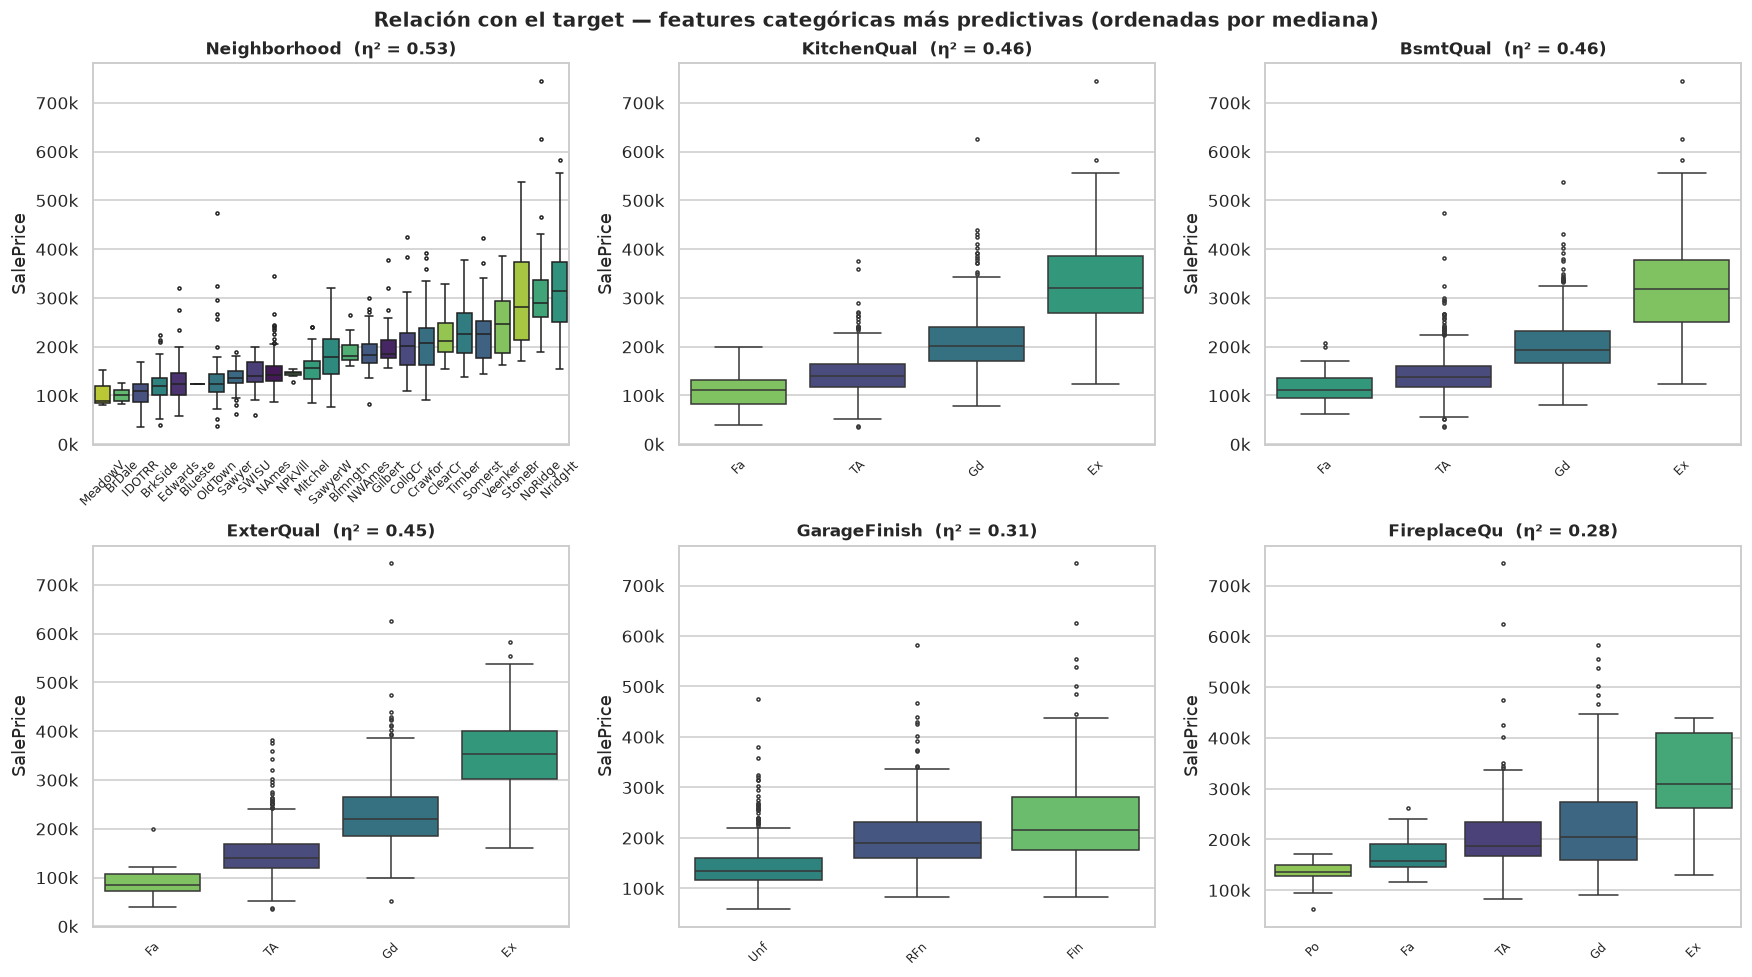

In [31]:
top_cat = eta.head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.ravel(), top_cat):
    orden = df.groupby(col, observed=True)[TARGET].median().sort_values().index
    sns.boxplot(x=df[col], y=y, order=orden, ax=ax, fliersize=2, palette="viridis",
                hue=df[col], legend=False)
    ax.set_title(f"{col}  (η² = {eta[col]:.2f})")
    ax.set_xlabel("")
    ax.set_ylabel("SalePrice")
    ax.yaxis.set_major_formatter(lambda v, p: f"{v/1000:.0f}k")
    ax.tick_params(axis="x", rotation=45, labelsize=8)

fig.suptitle("Relación con el target — features categóricas más predictivas "
             "(ordenadas por mediana)", fontsize=13, fontweight="bold")
fig.tight_layout()
save_fig(fig, "08_categoricas_vs_target")
plt.show()

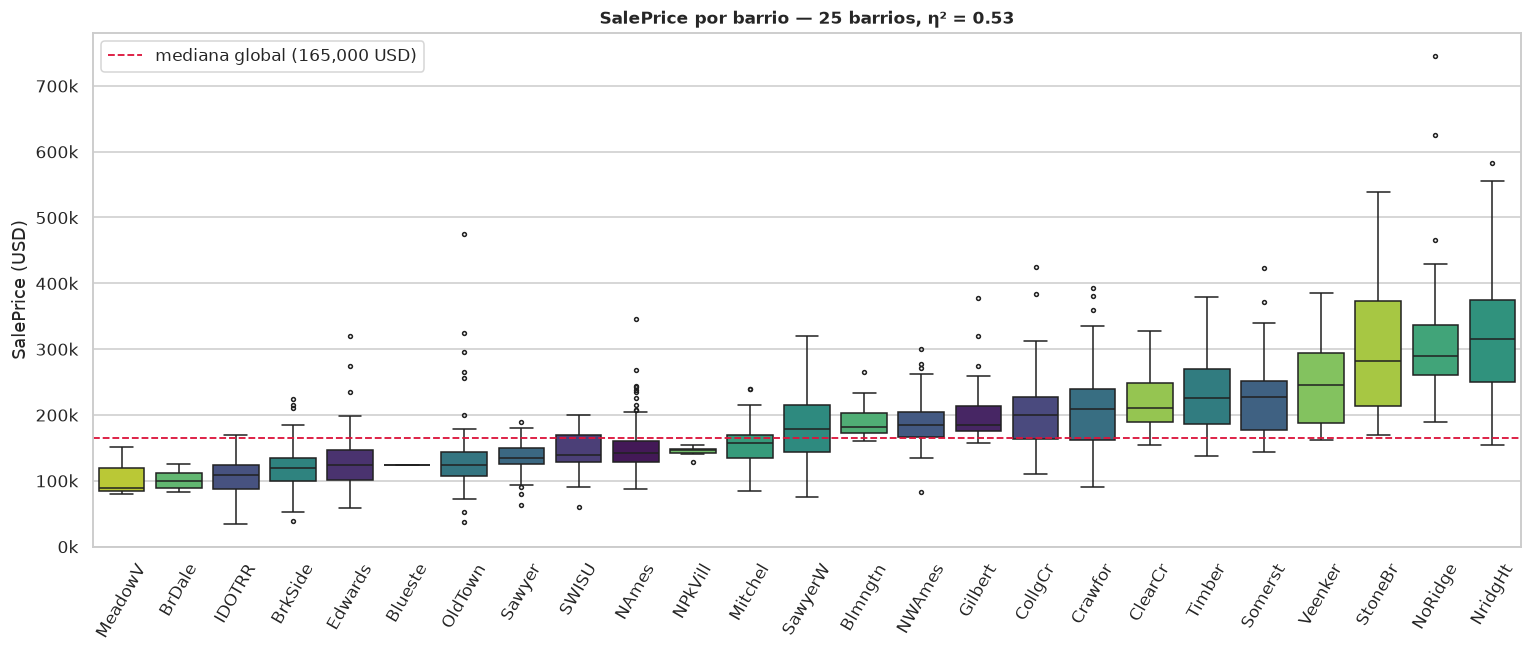

,count,median,mean,std
Neighborhood,,,,
MeadowV,10,89500.0,101890.0,25722.0
BrDale,13,100000.0,100915.0,13485.0
IDOTRR,26,108950.0,106623.0,30665.0
BrkSide,45,120000.0,122640.0,39075.0
Edwards,87,123500.0,127909.0,42166.0
Blueste,1,124000.0,124000.0,NaN
OldTown,91,124000.0,132887.0,56762.0
Sawyer,58,134950.0,136868.0,24215.0
SWISU,21,139500.0,144823.0,34453.0


In [32]:
# Neighborhood: la categórica de mayor cardinalidad y una de las más predictivas
barrio = df.groupby("Neighborhood")[TARGET].agg(["count", "median", "mean", "std"]) \
           .sort_values("median")

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(x="Neighborhood", y=TARGET, data=df, order=barrio.index, ax=ax,
            fliersize=2.5, palette="viridis", hue="Neighborhood", legend=False)
ax.axhline(y.median(), color="crimson", ls="--", lw=1.2,
           label=f"mediana global ({y.median():,.0f} USD)")
ax.set_title(f"SalePrice por barrio — {df['Neighborhood'].nunique()} barrios, "
             f"η² = {eta['Neighborhood']:.2f}")
ax.set_ylabel("SalePrice (USD)")
ax.set_xlabel("")
ax.yaxis.set_major_formatter(lambda v, p: f"{v/1000:.0f}k")
ax.tick_params(axis="x", rotation=60)
ax.legend()
fig.tight_layout()
save_fig(fig, "09_neighborhood")
plt.show()

barrio.round(0)

---
## 10. Features derivadas candidatas

El EDA sugiere agregados que condensan varias columnas correlacionadas en una sola señal más
fuerte. Se evalúan aquí para decidir si vale la pena construirlas en el pipeline.

In [33]:
cand = pd.DataFrame(index=df.index)
cand["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]
cand["TotalBaths"] = (df["FullBath"] + 0.5 * df["HalfBath"]
                      + df["BsmtFullBath"] + 0.5 * df["BsmtHalfBath"])
cand["HouseAge"] = df["YrSold"] - df["YearBuilt"]
cand["RemodAge"] = df["YrSold"] - df["YearRemodAdd"]
cand["IsRemodeled"] = (df["YearRemodAdd"] != df["YearBuilt"]).astype(int)
cand["TotalPorchSF"] = (df["OpenPorchSF"] + df["EnclosedPorch"] + df["3SsnPorch"]
                        + df["ScreenPorch"] + df["WoodDeckSF"])
cand["HasGarage"] = (df["GarageArea"] > 0).astype(int)
cand["HasBsmt"] = (df["TotalBsmtSF"] > 0).astype(int)
cand["HasFireplace"] = (df["Fireplaces"] > 0).astype(int)
cand["Has2ndFlr"] = (df["2ndFlrSF"] > 0).astype(int)
cand["OverallGrade"] = df["OverallQual"] * df["OverallCond"]
cand["QualPerSF"] = df["OverallQual"] / df["GrLivArea"]

comparacion = pd.DataFrame({
    "corr_SalePrice": cand.corrwith(y),
    "corr_log_SalePrice": cand.corrwith(np.log1p(y)),
}).round(3).sort_values("corr_SalePrice", ascending=False, key=abs)

mejor_original = rank_num["pearson"].abs().max()
print(f"Mejor feature original: {rank_num['pearson'].abs().idxmax()} "
      f"(|r| = {mejor_original:.3f})\n")
comparacion

Mejor feature original: OverallQual (|r| = 0.786)



,corr_SalePrice,corr_log_SalePrice
TotalSF,0.766,0.762
TotalBaths,0.621,0.659
OverallGrade,0.555,0.594
HouseAge,-0.516,-0.577
RemodAge,-0.510,-0.564
HasFireplace,0.471,0.507
TotalPorchSF,0.389,0.396
HasGarage,0.248,0.342
QualPerSF,-0.221,-0.221
HasBsmt,0.156,0.208


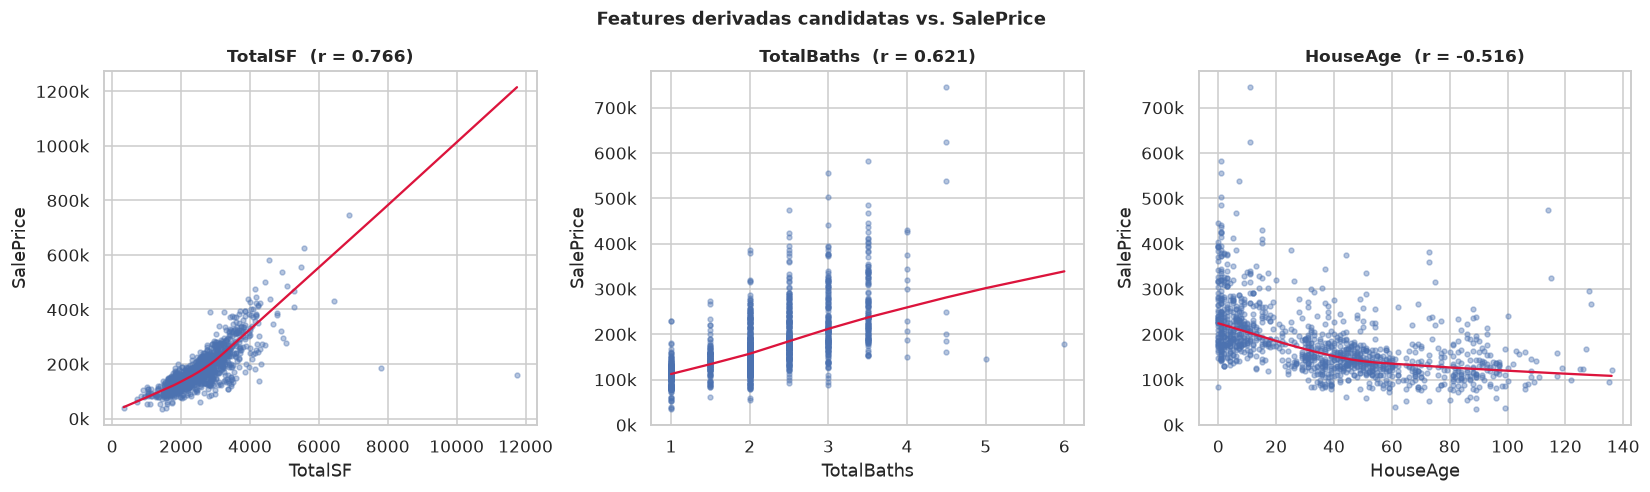

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, ["TotalSF", "TotalBaths", "HouseAge"]):
    sns.regplot(x=cand[col], y=y, ax=ax, scatter_kws=dict(s=10, alpha=0.4),
                line_kws=dict(color="crimson", lw=1.5), lowess=True)
    ax.set_title(f"{col}  (r = {comparacion.loc[col, 'corr_SalePrice']:.3f})")
    ax.set_ylabel("SalePrice")
    ax.yaxis.set_major_formatter(lambda v, p: f"{v/1000:.0f}k")
fig.suptitle("Features derivadas candidatas vs. SalePrice", fontsize=12, fontweight="bold")
fig.tight_layout()
save_fig(fig, "10_features_derivadas")
plt.show()

---
## 11. Decisiones de preprocesamiento derivadas del EDA

Cada decisión se enlaza con la evidencia de la sección que la produjo. Las marcadas como
*hipótesis* se validarán con A/B en la sección 2.3 (Resultados de iteraciones); las marcadas
como *firme* se aplican sin discusión porque corrigen un defecto objetivo del dato.

| # | Decisión | Evidencia (§) | Justificación | Estado |
|---|---|---|---|---|
| 0 | Leer el CSV con `keep_default_na=False, na_values=[""]` | §1.1 | pandas convierte los literales `"NA"` y `"None"` —categorías válidas— en `NaN`; 677 viviendas "sin revestimiento" aparecían como datos perdidos | Firme |
| 1 | Eliminar `Id` del set de features | §1 | Identificador único sin señal; el modelo podría memorizarlo | Firme |
| 2 | Quitar comillas simples literales de las categóricas | §1.2 | 3 columnas afectadas (`MSZoning`, `Exterior1st`, `Exterior2nd`); sin limpiar se duplican niveles al codificar | Firme |
| 3 | Tratar `MSSubClass` como nominal, no numérica | §2 | Sus valores son códigos de clase; el orden numérico es artificial | Firme |
| 4 | Codificar las 21 ordinales con mapeo entero ordenado | §2 | Preserva `Po < Fa < TA < Gd < Ex`, que one-hot destruiría, y ahorra 67 columnas dummy | Firme |
| 5 | Rellenar el `NA` estructural con la categoría `"None"` / `0` | §5 | Significa "no tiene la característica"; verificado al 100 % contra `TotalBsmtSF == 0` (n=28), `GarageArea == 0` (n=64) y `PoolArea == 0` (n=1162) | Firme |
| 6 | Imputar `LotFrontage` con la mediana **por barrio** | §5 | 18.6 % de nulos; el t-test (p = 0.86) descarta relación con el precio, y la mediana varía entre 21 y 91.5 ft según el barrio | Firme |
| 7 | Imputar `Electrical`, `MasVnrType` y `MasVnrArea` con moda / `"None"` / 0 | §5 | 1, 6 y 6 nulos respectivamente; impacto marginal | Firme |
| 8 | Agrupar categorías con n < 5 en `"Other"` | §7 | 42 niveles raros en 17 columnas generan dummies casi vacías y pueden no aparecer en el set de prueba | Hipótesis |
| 9 | Descartar las 9 columnas cuasi-constantes (>97 % un valor) | §7 | Varianza casi nula (`Utilities` es 99.9 % `AllPub`, η² = 0.000); solo añaden parámetros | Hipótesis |
| 10 | **Estandarizar** todas las numéricas (`StandardScaler`) | §4 | Las escalas van de 10⁰ a 10⁵; sin escalar, el descenso de gradiente se vuelve mal condicionado y las features grandes dominan la inicialización | Firme |
| 11 | Ajustar el escalador **solo con el set de entrenamiento** | §4 | Evita fuga de información hacia validación/prueba | Firme |
| 12 | Aplicar `log1p` a las numéricas con skew > 0.75 | §4 | Casos extremos como `MiscVal` (skew 22.0), `PoolArea` (14.4) y `LotArea` (12.0) dominarían la escala | Hipótesis |
| 13 | Entrenar sobre `log1p(SalePrice)` y revertir con `expm1` | §3 | Skew 1.74 → 0.12; evita que las casas caras dominen el gradiente. Requiere validar contra el RMSE en escala original | Hipótesis |
| 14 | One-hot a las nominales, con `handle_unknown="ignore"` | §2 | Sin orden natural; `ignore` protege contra categorías nuevas en el set de prueba del día de la competencia | Firme |
| 15 | Añadir `TotalSF`, `TotalBaths`, `HouseAge`, `TotalPorchSF` | §10 | Condensan columnas colineales en una sola señal; `TotalSF` compite con la mejor feature original (`OverallQual`, r = 0.786) | Hipótesis |
| 16 | Evaluar la eliminación de los 2 puntos influyentes (`Id` 524 y 1299) | §6 | `GrLivArea` > 4000 ft² con `OverallQual = 10` vendidas a 184 k y 160 k: ventas `Partial` de obra sin terminar que rompen la relación área–precio | Hipótesis (A/B) |
| 17 | **No** recortar outliers por regla del IQR | §6 | Son viviendas legítimas; el set de prueba tendrá casos igualmente extremos | Firme |
| 18 | Consolidar los 4 pares con \|r\| > 0.8 en una sola feature | §8 | `GarageArea`/`GarageCars` (0.88), `1stFlrSF`/`TotalBsmtSF` (0.83), `GrLivArea`/`TotRmsAbvGrd` (0.82), `GarageYrBlt`/`YearBuilt` (0.82) | Hipótesis |
| 19 | Split estratificado por cuantil de `SalePrice` | §3 | Con una cola derecha larga, un split aleatorio puro puede dejar los precios altos mal repartidos | Firme |
| 20 | Regularización fuerte desde la primera iteración | §2 | ~232 features tras codificar vs. 1168 observaciones (≈5:1) hace del sobreajuste el riesgo dominante | Firme |
| 21 | Conservar las filas con violaciones lógicas menores | §7 | 5 garajes anteriores a la casa y 4 viviendas sin dormitorio sobre rasante: son plausibles, no errores de captura | Firme |

In [35]:
# Contrato de preprocesamiento: lo consumirán los notebooks de modelado para garantizar
# que el pipeline aplicado al set de prueba sea idéntico al del entrenamiento.
contrato = {
    "target": TARGET,
    "id_col": ID_COL,
    "n_observaciones": int(len(df)),
    "columnas": {
        "continuas": sorted(CONTINUOUS_COLS),
        "discretas": sorted(DISCRETE_COLS),
        "ordinales_numericas": sorted(NUM_ORDINAL),
        "ordinales_categoricas": sorted(ORDINAL_COLS),
        "nominales": sorted(NOMINAL_COLS),
        "temporales": sorted(TEMPORAL_COLS),
    },
    "ordinal_maps": {c: niveles for c, niveles in ORDINAL_MAPS.items()},
    "na_estructural": sorted(NA_ESTRUCTURAL),
    "na_genuino": sorted(set(tabla_nulos.index) - set(NA_ESTRUCTURAL)),
    "columnas_cuasi_constantes": casi_const_df["columna"].tolist(),
    "skew_alto": sorted(df[num_cols_all].skew()[lambda s: s.abs() > 0.75].index.tolist()),
    "ids_influyentes": influyentes[ID_COL].tolist(),
    "features_derivadas": sorted(cand.columns.tolist()),
    "target_stats": {
        "media": float(y.mean()), "mediana": float(y.median()),
        "std": float(y.std()), "skew": float(y.skew()),
        "skew_log1p": float(np.log1p(y).skew()),
        "min": float(y.min()), "max": float(y.max()),
    },
}

destino = DATA_PROC / "column_types.json"
destino.write_text(json.dumps(contrato, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"Contrato de preprocesamiento guardado en: {destino.relative_to(ROOT)}")
print(f"Figuras generadas en {FIGURES.relative_to(ROOT)}:")
for f in sorted(FIGURES.glob('*.png')):
    print(f"  - {f.name}")

Contrato de preprocesamiento guardado en: data/processed/column_types.json
Figuras generadas en reports/figures:
  - 01_target_distribucion.png
  - 02_valores_nulos.png
  - 03_outliers_bivariados.png
  - 04_outliers_boxplots.png
  - 05_matriz_correlacion.png
  - 06_ranking_features.png
  - 07_features_vs_target.png
  - 08_categoricas_vs_target.png
  - 09_neighborhood.png
  - 10_features_derivadas.png


---
## 12. Síntesis del EDA

**El dataset.** 1168 viviendas de Ames (Iowa) vendidas entre 2006 y 2010, descritas por 79
features y un precio de venta. La mezcla es heterogénea: 35 numéricas de escalas muy dispares
(de 10⁰ en `BsmtHalfBath` a 10⁵ en `LotArea`), 21 ordinales con orden semántico explícito y 23
nominales, una de ellas (`Neighborhood`) con 25 niveles. No hay filas duplicadas ni identificadores
repetidos, y la cobertura temporal es homogénea salvo 2010, que solo llega hasta mitad de año.

**El target.** `SalePrice` es fuertemente asimétrico a la derecha (skew 1.74, curtosis 5.48),
con un rango de 34 900 a 745 000 USD. La transformación `log1p` lo normaliza casi por completo
(skew 0.12), lo que abre una decisión de modelado que hay que validar: la métrica se mide en la
escala original, así que entrenar en log solo conviene si el RMSE tras `expm1` mejora.

**Los problemas del dato.** (a) La lectura ingenua del CSV destruye 677 categorías legítimas,
porque `pandas` interpreta los literales `"NA"` y `"None"` como nulos — corregido con
`keep_default_na=False`; (b) comillas simples literales en 3 columnas, que duplicarían niveles al
codificar; (c) 19 columnas con nulos, pero la mayoría son `NA` estructurales verificados al 100 %
contra sus áreas correspondientes (`TotalBsmtSF == 0`, `GarageArea == 0`, `PoolArea == 0`); el
único faltante genuino relevante es `LotFrontage` (18.6 %), imputable por mediana de barrio;
(d) dos puntos influyentes (`Id` 524 y 1299) con área enorme y precio bajo; (e) dos violaciones
lógicas menores —5 garajes anteriores a la vivienda y 4 casas sin dormitorio sobre rasante— que
tras inspección resultan plausibles y no errores de captura.

**La señal.** `OverallQual` (r = 0.786) y `GrLivArea` (r = 0.696) dominan entre las numéricas;
`Neighborhood` es la categórica más informativa (η² = 0.53), seguida de `KitchenQual`, `BsmtQual`
y `ExterQual` (η² ≈ 0.46). La relación de varias features con el precio es claramente **no lineal**
(los ajustes LOWESS se curvan en `OverallQual` y `TotalSF`), lo que justifica el MLP frente a un
modelo lineal. Hay multicolinealidad apreciable: 6 pares con |r| ≥ 0.65, todos entre features que
miden lo mismo (garaje, superficie, año).

**La restricción dominante.** Tras codificar, la dimensionalidad ronda las 232 features para
1168 observaciones. Esa razón ≈5:1 hace que el riesgo principal del proyecto no sea la capacidad
del modelo sino el **sobreajuste**: la regularización y el control de la dimensionalidad serán
las palancas con mayor impacto sobre el RMSE de la competencia.

---

**Siguiente paso →** `02_preprocesamiento.ipynb`: implementar el pipeline con las decisiones
firmes de §11 y dejarlo serializado, para que el mismo objeto se aplique tal cual al dataset
de prueba del día de la presentación.